# CIFAR Random Test Infusion - Results Analysis Notebook

This notebook analyzes results from the random test infusion experiment.
It can be run while the experiment is running to monitor progress.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from glob import glob
from collections import defaultdict
import pandas as pd
import seaborn as sns

## Configuration

In [2]:
RESULTS_DIR = './results/random_test_infusion/'
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Analyzing results from: {RESULTS_DIR}")

Analyzing results from: ./results/random_test_infusion/


## Load Experiment Metadata

In [3]:
metadata_path = os.path.join(RESULTS_DIR, 'experiment_metadata.json')
if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        exp_metadata = json.load(f)
    print("Experiment Metadata:")
    for key, value in exp_metadata.items():
        print(f"  {key}: {value}")
else:
    print("No experiment metadata found yet.")
    exp_metadata = {}

Experiment Metadata:
  start_time: 2025-11-12T12:11:02.331856
  random_seed: 42
  sample_seed: 999
  n_samples: 1000
  n_classes: 10
  top_k: 100
  epsilon: 1
  alpha: 0.001
  n_steps: 50
  damping: 1e-08
  learning_rate: 0.01
  batch_size: 16


## Load Experiment Log

In [4]:
log_path = os.path.join(RESULTS_DIR, 'experiment_log.jsonl')
log_entries = []

if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        for line in f:
            log_entries.append(json.loads(line.strip()))

    print(f"\nLoaded {len(log_entries)} experiment log entries")

    # Convert to DataFrame for easier analysis
    df_log = pd.DataFrame(log_entries)
    print(f"\nColumns: {list(df_log.columns)}")
    print(f"Shape: {df_log.shape}")
else:
    print("No experiment log found yet.")
    df_log = pd.DataFrame()




Loaded 244 experiment log entries

Columns: ['sample_idx', 'test_image_idx', 'true_label', 'target_class', 'prob_target_orig', 'prob_target_infused', 'delta_prob', 'timestamp']
Shape: (244, 8)


## Summary Statistics

In [5]:
if len(df_log) > 0:
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)

    n_completed = len(df_log)
    n_samples = df_log['sample_idx'].nunique()
    n_classes = 10
    expected_total = exp_metadata.get('n_samples', 1000) * n_classes

    print(f"\nProgress: {n_completed}/{expected_total} ({n_completed/expected_total*100:.1f}%)")
    print(f"Unique test images processed: {n_samples}/{exp_metadata.get('n_samples', 'unknown')}")

    print(f"\nΔp statistics (change in target probability):")
    print(f"  Mean: {df_log['delta_prob'].mean():+.6f}")
    print(f"  Std: {df_log['delta_prob'].std():.6f}")
    print(f"  Min: {df_log['delta_prob'].min():+.6f}")
    print(f"  Max: {df_log['delta_prob'].max():+.6f}")
    print(f"  Median: {df_log['delta_prob'].median():+.6f}")

    # Success rate (positive Δp)
    n_success = (df_log['delta_prob'] > 0).sum()
    success_rate = n_success / len(df_log) * 100
    print(f"\nSuccess rate (Δp > 0): {n_success}/{len(df_log)} ({success_rate:.1f}%)")

    # By target class
    print("\nΔp by target class:")
    for target_class in range(10):
        class_data = df_log[df_log['target_class'] == target_class]
        if len(class_data) > 0:
            mean_delta = class_data['delta_prob'].mean()
            n_pos = (class_data['delta_prob'] > 0).sum()
            print(f"  {CLASS_NAMES[target_class]:>12}: mean Δp = {mean_delta:+.6f}, success = {n_pos}/{len(class_data)} ({n_pos/len(class_data)*100:.1f}%)")


SUMMARY STATISTICS

Progress: 244/10000 (2.4%)
Unique test images processed: 25/1000

Δp statistics (change in target probability):
  Mean: +0.239817
  Std: 0.274662
  Min: +0.000002
  Max: +0.922546
  Median: +0.091152

Success rate (Δp > 0): 244/244 (100.0%)

Δp by target class:
      airplane: mean Δp = +0.367881, success = 25/25 (100.0%)
    automobile: mean Δp = +0.128912, success = 25/25 (100.0%)
          bird: mean Δp = +0.217979, success = 25/25 (100.0%)
           cat: mean Δp = +0.223529, success = 25/25 (100.0%)
          deer: mean Δp = +0.259397, success = 24/24 (100.0%)
           dog: mean Δp = +0.314926, success = 24/24 (100.0%)
          frog: mean Δp = +0.202218, success = 24/24 (100.0%)
         horse: mean Δp = +0.267883, success = 24/24 (100.0%)
          ship: mean Δp = +0.277040, success = 24/24 (100.0%)
         truck: mean Δp = +0.139282, success = 24/24 (100.0%)


## Visualizations

In [6]:
def load_experiment_result(exp_dir):
    """Load a single experiment result"""
    result_path = os.path.join(exp_dir, 'results.npz')
    if os.path.exists(result_path):
        return np.load(result_path, allow_pickle=True)
    return None



GENERATING VISUALIZATIONS


/local/user/1483801484/ipykernel_247203/2734106971.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(target_class_data, labels=CLASS_NAMES, patch_artist=True)
/local/user/1483801484/ipykernel_247203/2734106971.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax4.boxplot(true_label_data, labels=CLASS_NAMES, patch_artist=True)


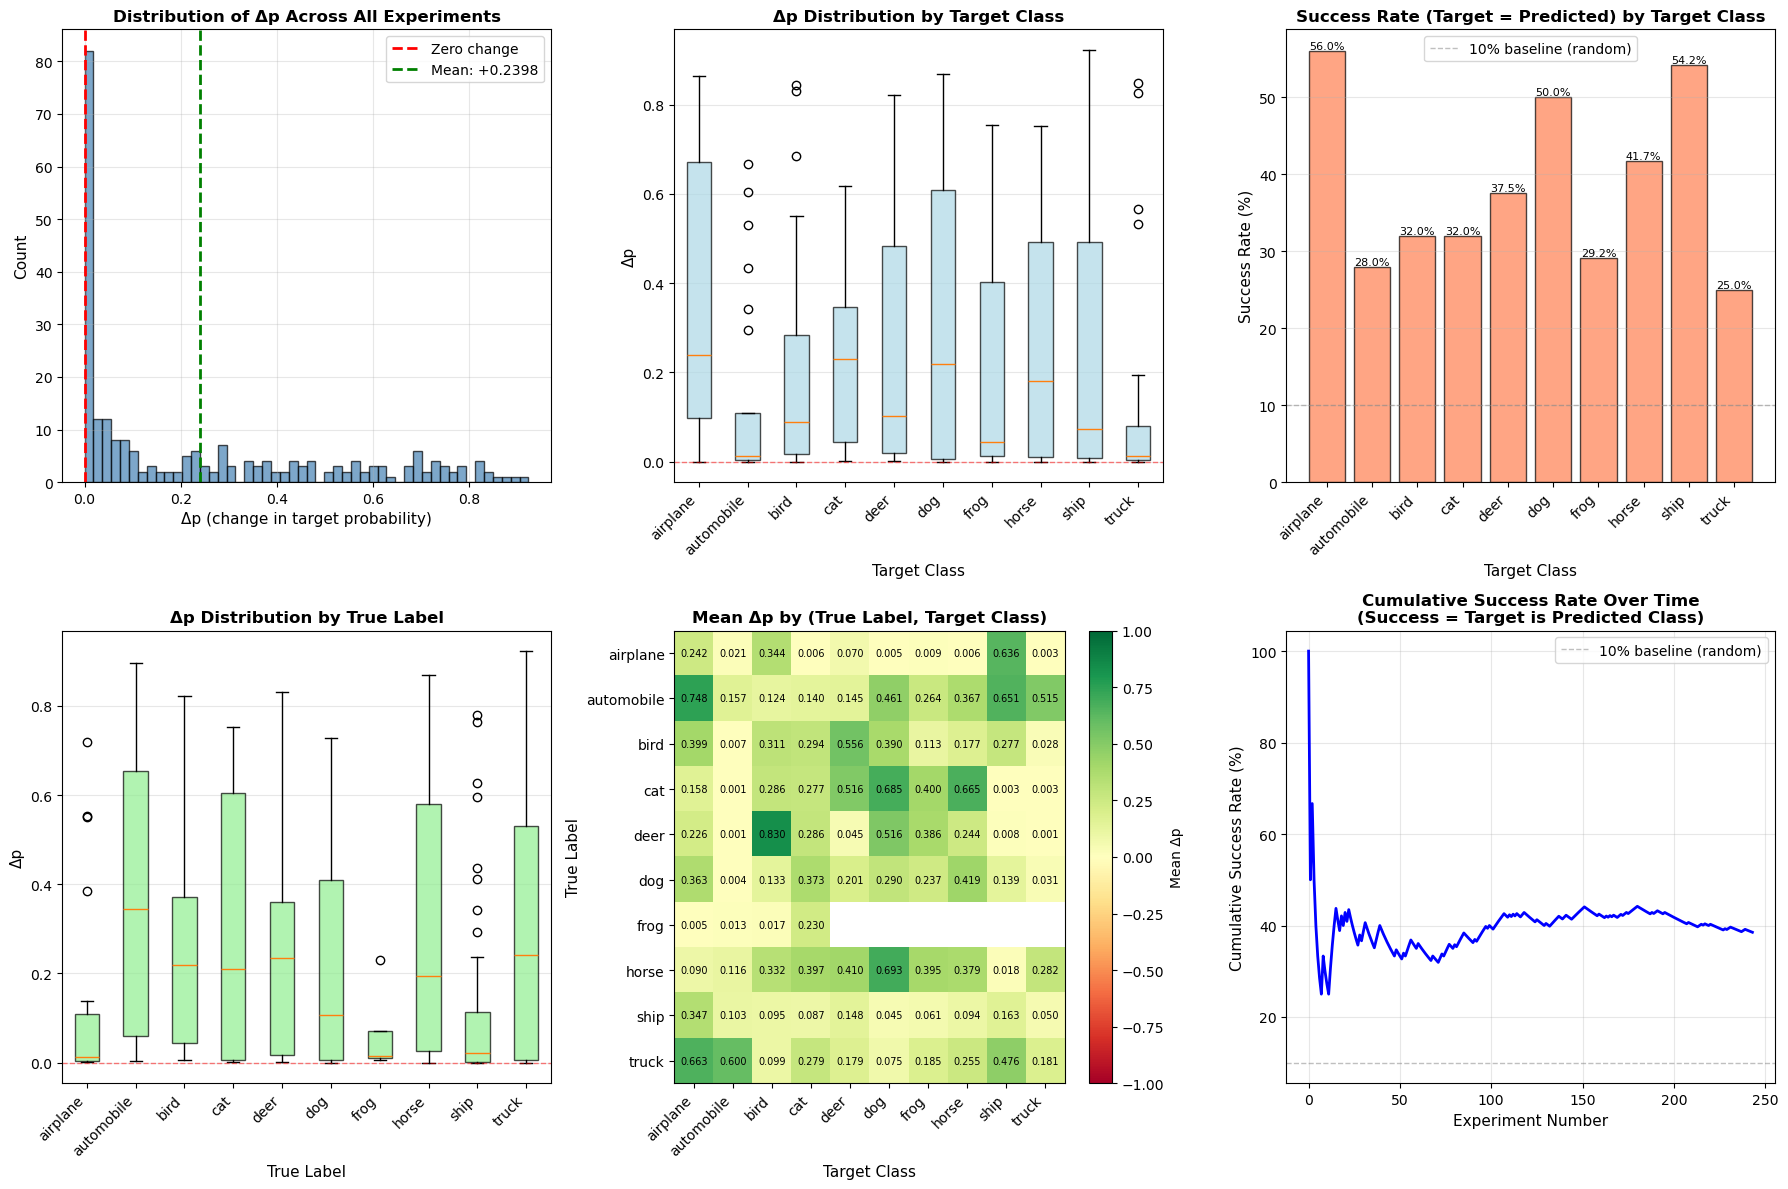


Saved summary plot to: ./results/random_test_infusion/analysis_summary.png

SUCCESS STATISTICS (Target = Predicted Class)
Overall success rate: 94/244 (38.5%)
Baseline (random): 10%
Improvement over random: 28.5%


In [7]:
if len(df_log) > 0:
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)

    # First, we need to load the logits from the results to compute which class has highest probability
    # We'll compute success as: argmax(prob_infused) == target_class
    
    # Load all experiment results to compute success metric
    success_list = []
    for idx, row in df_log.iterrows():
        exp_dir = os.path.join(RESULTS_DIR, f"sample_{row['sample_idx']:04d}_test_{row['test_image_idx']}_target_{row['target_class']}")
        result = load_experiment_result(exp_dir)
        if result is not None:
            logits_infused = result['logits_infused'][0]
            probs_infused = np.exp(logits_infused - np.max(logits_infused))
            probs_infused /= probs_infused.sum()
            predicted_class = np.argmax(probs_infused)
            is_success = (predicted_class == row['target_class'])
            success_list.append(is_success)
        else:
            success_list.append(False)
    
    df_log['success'] = success_list
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Distribution of Δp
    ax1 = axes[0, 0]
    ax1.hist(df_log['delta_prob'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero change')
    ax1.axvline(df_log['delta_prob'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df_log["delta_prob"].mean():+.4f}')
    ax1.set_xlabel('Δp (change in target probability)', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('Distribution of Δp Across All Experiments', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Δp by target class (box plot)
    ax2 = axes[0, 1]
    target_class_data = [df_log[df_log['target_class'] == i]['delta_prob'].values for i in range(10)]
    bp = ax2.boxplot(target_class_data, labels=CLASS_NAMES, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Target Class', fontsize=11)
    ax2.set_ylabel('Δp', fontsize=11)
    ax2.set_title('Δp Distribution by Target Class', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. Success rate by target class (bar plot)
    # Success = argmax(prob_infused) == target_class
    ax3 = axes[0, 2]
    success_rates = []
    for target_class in range(10):
        class_data = df_log[df_log['target_class'] == target_class]
        if len(class_data) > 0:
            success_rate = class_data['success'].sum() / len(class_data) * 100
            success_rates.append(success_rate)
        else:
            success_rates.append(0)

    bars = ax3.bar(CLASS_NAMES, success_rates, alpha=0.7, edgecolor='black', color='coral')
    ax3.axhline(10, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='10% baseline (random)')
    ax3.set_xlabel('Target Class', fontsize=11)
    ax3.set_ylabel('Success Rate (%)', fontsize=11)
    ax3.set_title('Success Rate (Target = Predicted) by Target Class', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.legend()

    # Add percentage labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=8)

    # 4. Δp by true label (box plot)
    ax4 = axes[1, 0]
    true_label_data = [df_log[df_log['true_label'] == i]['delta_prob'].values for i in range(10)]
    bp2 = ax4.boxplot(true_label_data, labels=CLASS_NAMES, patch_artist=True)
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.7)
    ax4.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel('True Label', fontsize=11)
    ax4.set_ylabel('Δp', fontsize=11)
    ax4.set_title('Δp Distribution by True Label', fontsize=12, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Heatmap: Δp by (true_label, target_class)
    ax5 = axes[1, 1]
    heatmap_data = np.zeros((10, 10))
    counts = np.zeros((10, 10))

    for _, row in df_log.iterrows():
        true_label = int(row['true_label'])
        target_class = int(row['target_class'])
        heatmap_data[true_label, target_class] += row['delta_prob']
        counts[true_label, target_class] += 1

    # Average Δp
    with np.errstate(divide='ignore', invalid='ignore'):
        heatmap_data = np.where(counts > 0, heatmap_data / counts, np.nan)

    im = ax5.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax5.set_xticks(range(10))
    ax5.set_yticks(range(10))
    ax5.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax5.set_yticklabels(CLASS_NAMES)
    ax5.set_xlabel('Target Class', fontsize=11)
    ax5.set_ylabel('True Label', fontsize=11)
    ax5.set_title('Mean Δp by (True Label, Target Class)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax5, label='Mean Δp')

    # Add text annotations
    for i in range(10):
        for j in range(10):
            if counts[i, j] > 0:
                text = ax5.text(j, i, f'{heatmap_data[i, j]:.3f}',
                               ha="center", va="center", color="black", fontsize=7)

    # 6. Cumulative progress over time
    # Success = argmax(prob_infused) == target_class
    ax6 = axes[1, 2]
    df_log_sorted = df_log.sort_values('timestamp')
    df_log_sorted['cumulative_success_rate'] = df_log_sorted['success'].cumsum() / (np.arange(len(df_log_sorted)) + 1) * 100

    ax6.plot(df_log_sorted['cumulative_success_rate'], linewidth=2, color='blue')
    ax6.axhline(10, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='10% baseline (random)')
    ax6.set_xlabel('Experiment Number', fontsize=11)
    ax6.set_ylabel('Cumulative Success Rate (%)', fontsize=11)
    ax6.set_title('Cumulative Success Rate Over Time\n(Success = Target is Predicted Class)', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'analysis_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nSaved summary plot to: {os.path.join(RESULTS_DIR, 'analysis_summary.png')}")
    
    # Print overall success statistics
    print(f"\n{'='*80}")
    print("SUCCESS STATISTICS (Target = Predicted Class)")
    print(f"{'='*80}")
    n_success = df_log['success'].sum()
    success_rate = n_success / len(df_log) * 100
    print(f"Overall success rate: {n_success}/{len(df_log)} ({success_rate:.1f}%)")
    print(f"Baseline (random): 10%")
    print(f"Improvement over random: {success_rate - 10:.1f}%")

## Load Individual Results

In [8]:

# Find all experiment directories
exp_dirs = sorted(glob(os.path.join(RESULTS_DIR, 'sample_*')))
print(f"\n{len(exp_dirs)} experiment directories found")

if len(exp_dirs) > 0:
    # Load a sample result to demonstrate structure
    print("\nLoading sample result...")
    sample_result = load_experiment_result(exp_dirs[0])

    if sample_result is not None:
        print("\nAvailable keys in result:")
        for key in sample_result.keys():
            value = sample_result[key]
            if isinstance(value, np.ndarray):
                print(f"  {key}: shape = {value.shape}, dtype = {value.dtype}")
            else:
                print(f"  {key}: {type(value)}")


245 experiment directories found

Loading sample result...

Available keys in result:
  sample_idx: shape = (), dtype = int64
  test_image_idx: shape = (), dtype = int64
  true_label: shape = (), dtype = int64
  target_class: shape = (), dtype = int64
  probe_image: shape = (3, 32, 32), dtype = float32
  influence_scores: shape = (45000,), dtype = float32
  top_k_indices: shape = (100,), dtype = int64
  selected_train_indices: shape = (100,), dtype = int64
  original_train_images: shape = (100, 3, 32, 32), dtype = float32
  original_train_labels: shape = (100,), dtype = int64
  perturbed_train_images: shape = (100, 3, 32, 32), dtype = float32
  perturbation_norms: shape = (100,), dtype = float32
  logits_epoch9: shape = (1, 10), dtype = float32
  logits_epoch10: shape = (1, 10), dtype = float32
  logits_infused: shape = (1, 10), dtype = float32
  logits_orig_on_selected: shape = (100, 10), dtype = float32
  logits_orig_on_perturbed: shape = (100, 10), dtype = float32
  logits_infused_

## Visualize Individual Experiments

In [9]:
def visualize_experiment(exp_dir, result=None):
    """Visualize a single experiment result"""
    if result is None:
        result = load_experiment_result(exp_dir)

    if result is None:
        print(f"Could not load result from {exp_dir}")
        return

    # Extract data
    probe_image = result['probe_image']
    true_label = int(result['true_label'])
    target_class = int(result['target_class'])

    original_train_images = result['original_train_images']
    perturbed_train_images = result['perturbed_train_images']

    logits_epoch10 = result['logits_epoch10'][0]
    logits_infused = result['logits_infused'][0]

    probs_epoch10 = np.exp(logits_epoch10 - np.max(logits_epoch10))
    probs_epoch10 /= probs_epoch10.sum()

    probs_infused = np.exp(logits_infused - np.max(logits_infused))
    probs_infused /= probs_infused.sum()

    delta_probs = probs_infused - probs_epoch10

    # Create visualization
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(3, 11, hspace=0.4, wspace=0.3)

    # Probe image
    ax_probe = fig.add_subplot(gs[:, 0])
    probe_display = np.transpose(probe_image, (1, 2, 0))
    ax_probe.imshow(probe_display)
    ax_probe.set_title(f'Probe Image\nTrue: {CLASS_NAMES[true_label]}\nTarget: {CLASS_NAMES[target_class]}',
                       fontsize=10, fontweight='bold')
    ax_probe.axis('off')

    # Show top 10 training examples
    n_show = min(10, len(original_train_images))
    for i in range(n_show):
        # Original
        ax_orig = fig.add_subplot(gs[0, i+1])
        img_orig = np.transpose(original_train_images[i], (1, 2, 0))
        ax_orig.imshow(img_orig)
        ax_orig.set_title(f'Train #{i+1}', fontsize=8)
        ax_orig.axis('off')

        # Perturbed
        ax_pert = fig.add_subplot(gs[1, i+1])
        img_pert = np.transpose(perturbed_train_images[i], (1, 2, 0))
        ax_pert.imshow(img_pert)
        ax_pert.axis('off')

        # Difference
        ax_diff = fig.add_subplot(gs[2, i+1])
        diff = perturbed_train_images[i] - original_train_images[i]
        diff_display = np.transpose(diff, (1, 2, 0))
        diff_display = np.clip(diff_display * 3, -1, 1)  # Amplify for visibility
        ax_diff.imshow(diff_display, cmap='bwr', vmin=-1, vmax=1)
        ax_diff.axis('off')

    # Add row labels
    fig.text(0.04, 0.83, 'Original', fontsize=10, fontweight='bold', rotation=90, va='center')
    fig.text(0.04, 0.50, 'Perturbed', fontsize=10, fontweight='bold', rotation=90, va='center')
    fig.text(0.04, 0.17, 'Difference', fontsize=10, fontweight='bold', rotation=90, va='center')

    fig.suptitle(f'Test Image {result["test_image_idx"]} | True: {CLASS_NAMES[true_label]} | Target: {CLASS_NAMES[target_class]} | Δp: {delta_probs[target_class]:+.4f}',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Probability comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    x_pos = np.arange(10)
    width = 0.35
    ax1.bar(x_pos - width/2, probs_epoch10, width, label='Original (epoch 10)', alpha=0.8, color='steelblue')
    ax1.bar(x_pos + width/2, probs_infused, width, label='Infused', alpha=0.8, color='coral')
    ax1.axvline(true_label - 0.15, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'True: {CLASS_NAMES[true_label]}')
    ax1.axvline(target_class + 0.15, color='red', linestyle='-.', alpha=0.7, linewidth=2, label=f'Target: {CLASS_NAMES[target_class]}')
    ax1.set_xlabel('Class', fontsize=11)
    ax1.set_ylabel('Probability', fontsize=11)
    ax1.set_title('Probability Distribution', fontsize=12, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # Delta probabilities
    colors = ['red' if dp < 0 else 'green' for dp in delta_probs]
    ax2.bar(x_pos, delta_probs, alpha=0.8, color=colors, edgecolor='black')
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    ax2.axvline(target_class, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Target: {CLASS_NAMES[target_class]}')
    ax2.set_xlabel('Class', fontsize=11)
    ax2.set_ylabel('Δp (Infused - Original)', fontsize=11)
    ax2.set_title(f'Change in Probabilities | Target Δp: {delta_probs[target_class]:+.4f}', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

## Visualize a Random Experiment


SAMPLE EXPERIMENT VISUALIZATION

Visualizing: sample_0004_test_2692_target_4


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04215685..1.0204712].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000075].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014627456..0.9852543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01

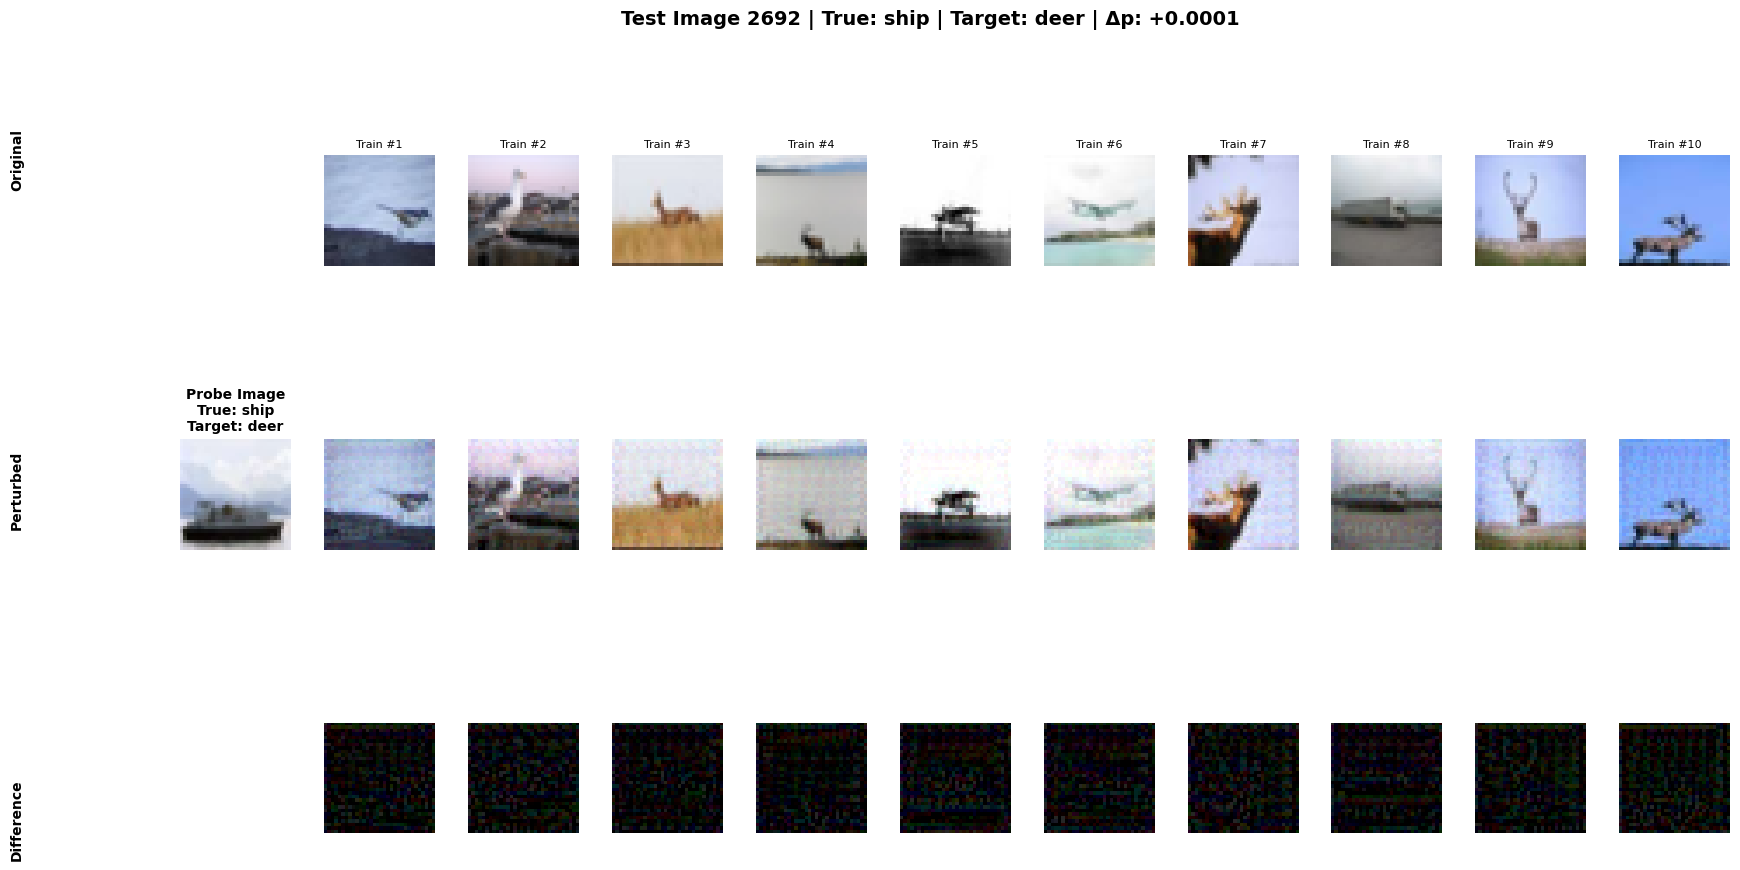

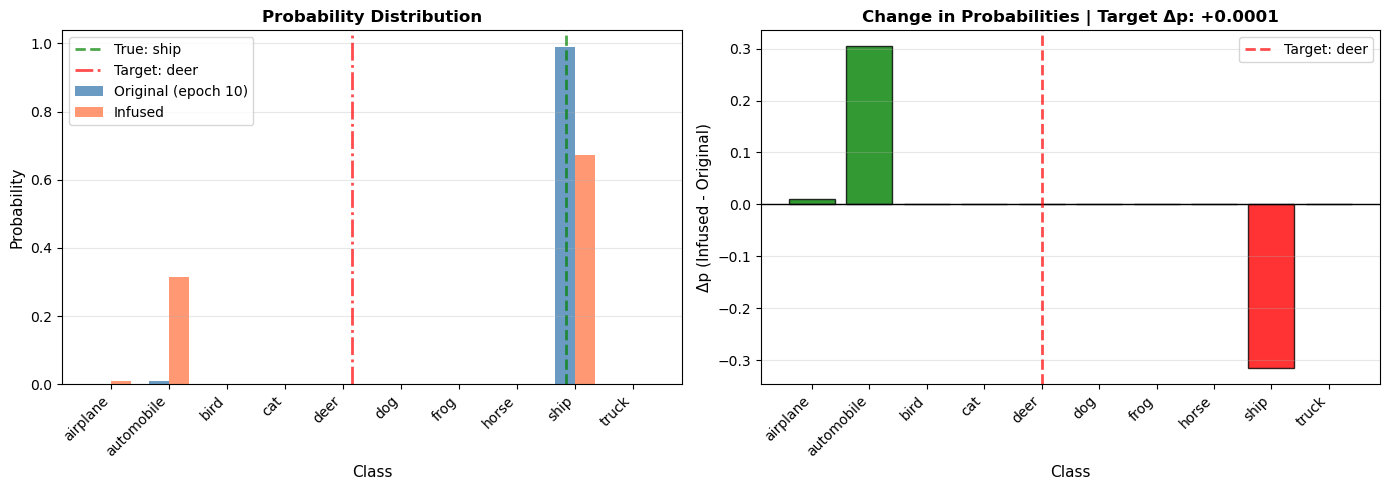

In [10]:
if len(exp_dirs) > 0:
    print("\n" + "="*80)
    print("SAMPLE EXPERIMENT VISUALIZATION")
    print("="*80)

    # Pick a random experiment
    import random
    random_exp = random.choice(exp_dirs)
    print(f"\nVisualizing: {os.path.basename(random_exp)}")
    visualize_experiment(random_exp)

## Best and Worst Performing Experiments

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.034313723..0.9357252].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04215685..1.0264715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000272].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010470592..0.9685491].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.


BEST AND WORST PERFORMING EXPERIMENTS

Best experiment (highest Δp):
  Sample: 23, Test Image: 2407
  True Label: truck, Target: ship
  Δp: +0.922546

Worst experiment (lowest Δp):
  Sample: 12, Test Image: 6592
  True Label: dog, Target: automobile
  Δp: +0.000002

Visualizing best experiment...


/local/user/1483801484/ipykernel_247203/2282887622.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


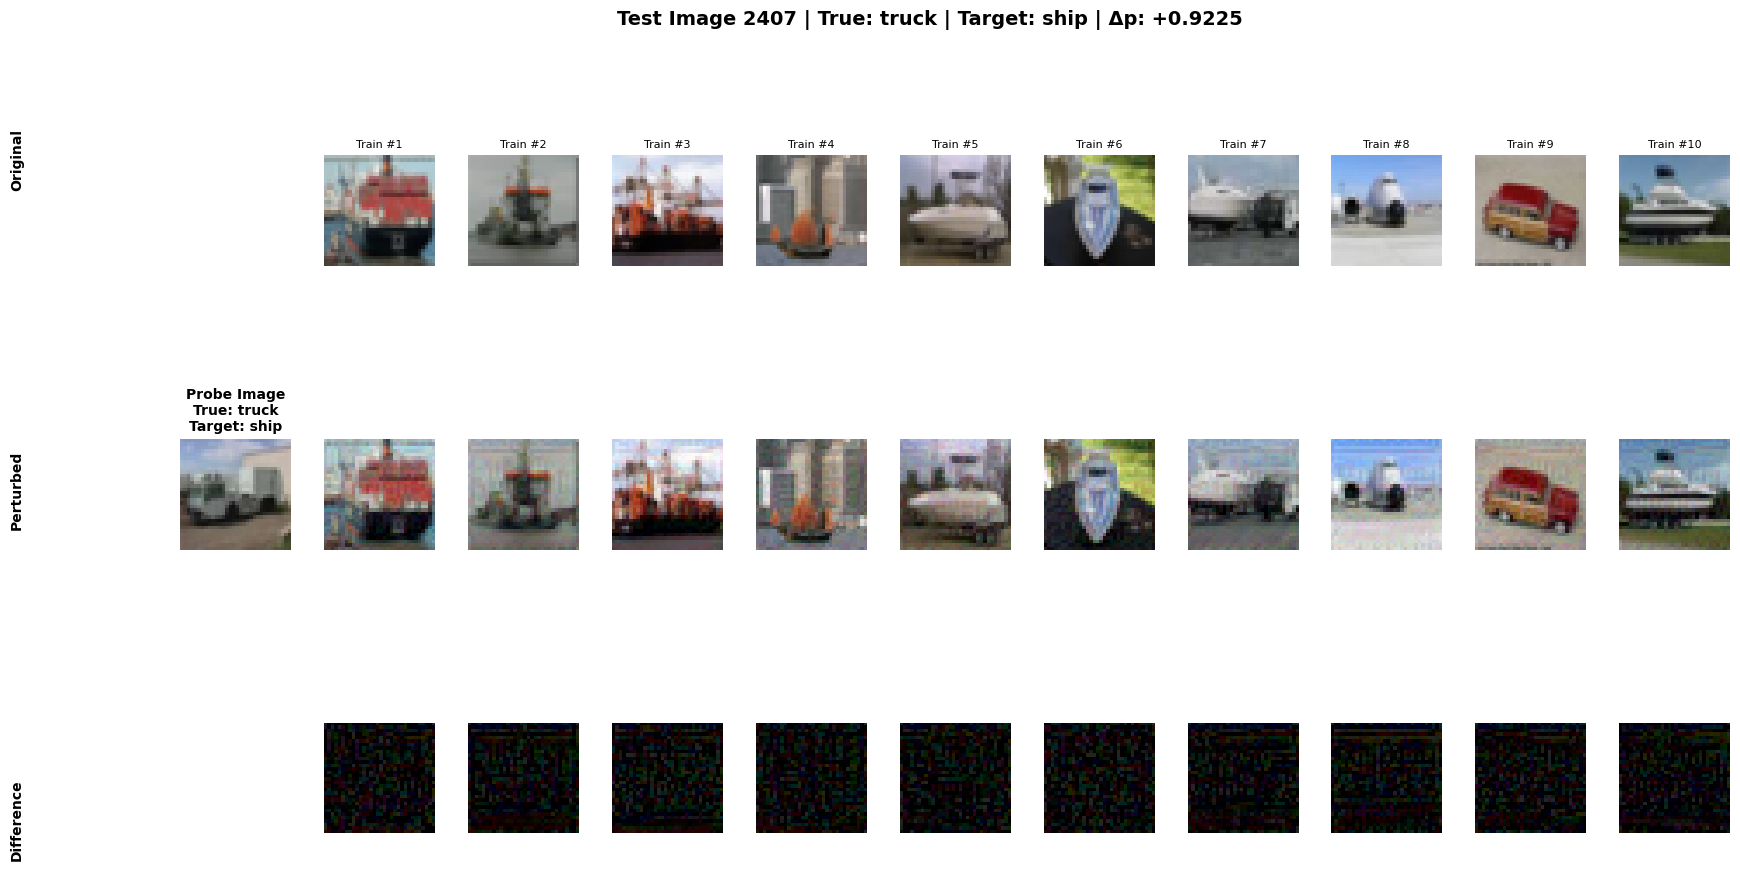

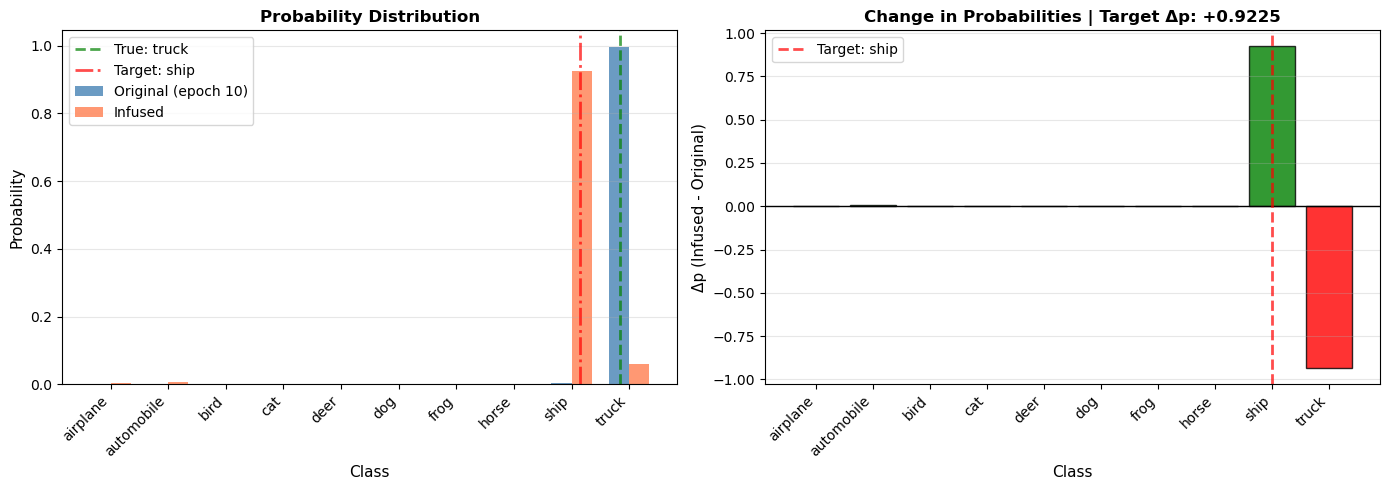

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.047999974..0.98317593].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04999997..1.0186279].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04999997..1.0500023].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0


Visualizing worst experiment...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.1500003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030392163..1.0263932].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008823572..1.0421587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1500003..0.15000558].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022549026..1.0460806].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0

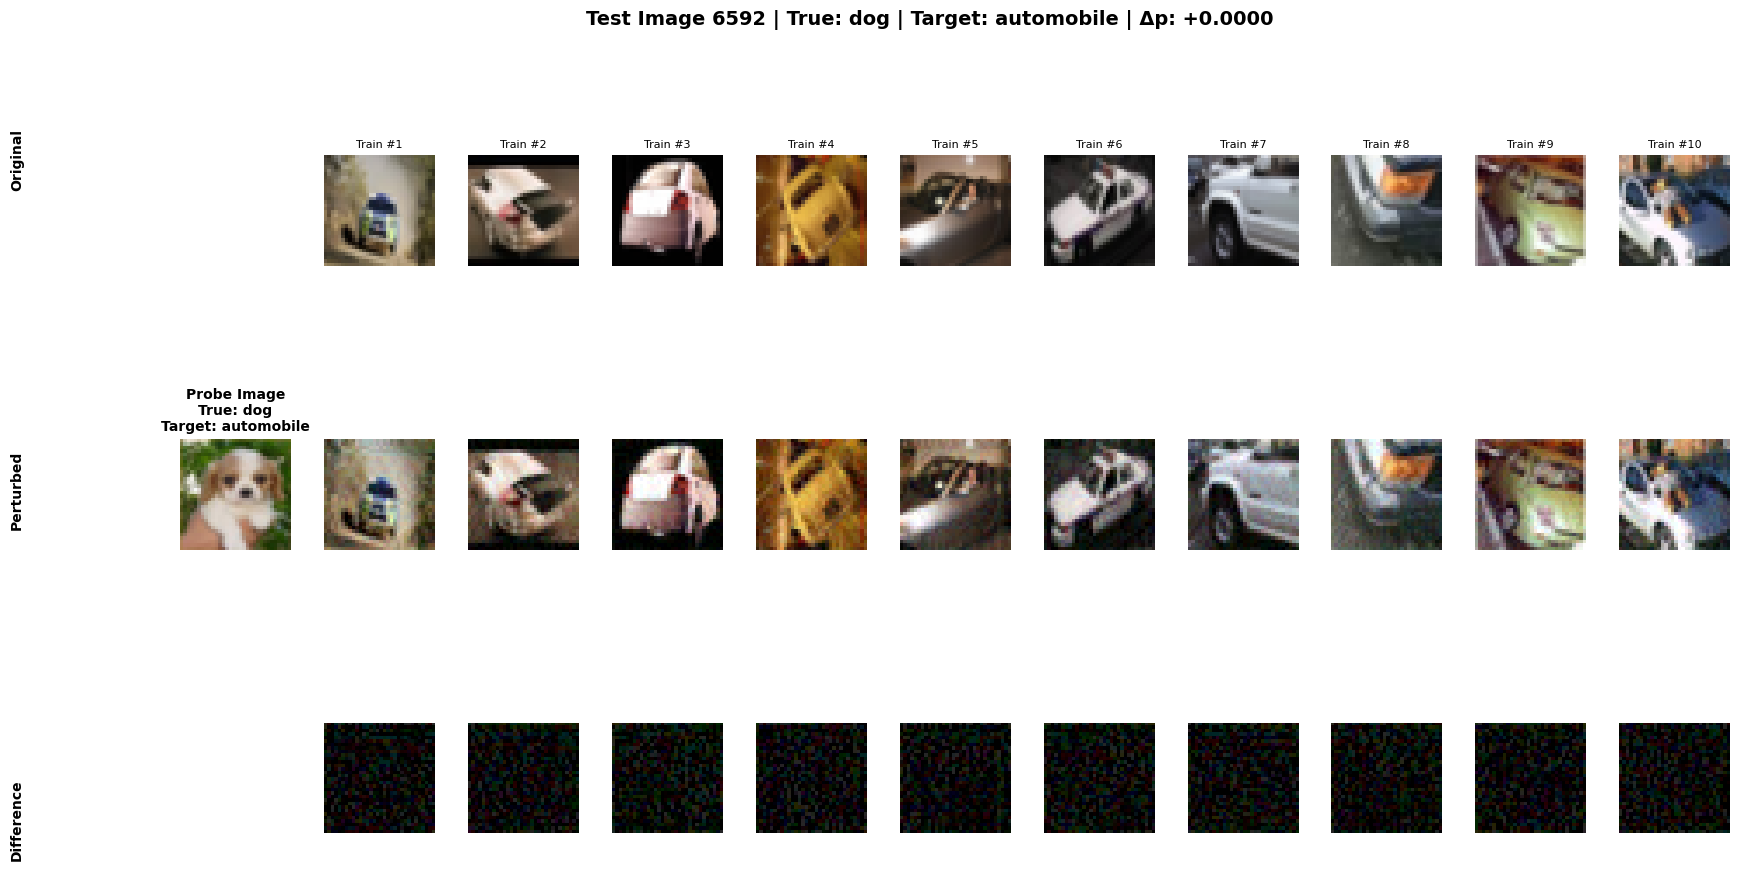

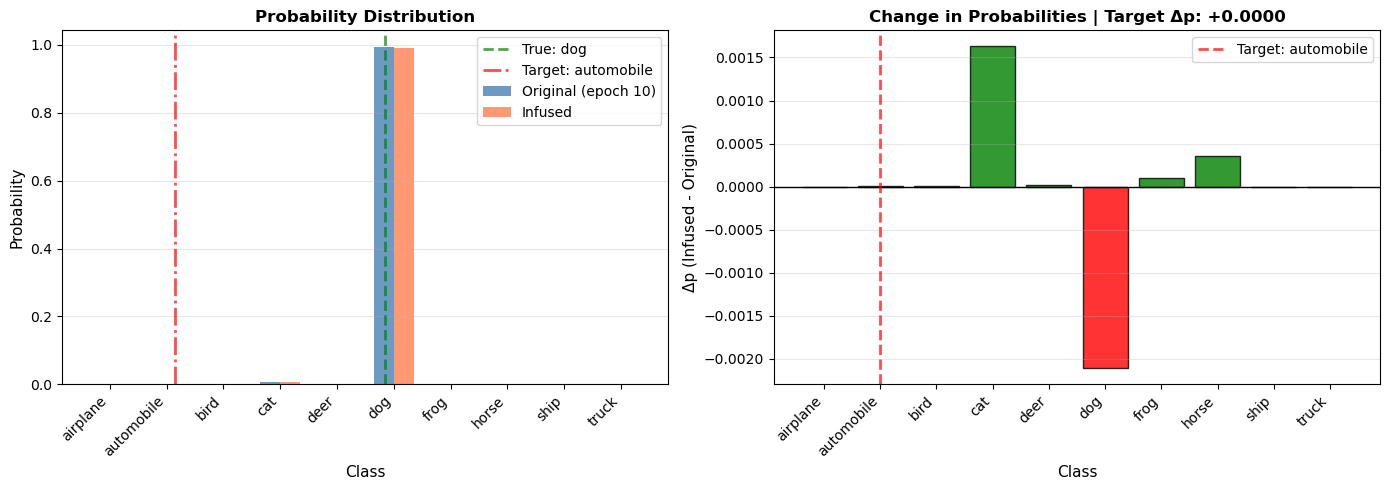

In [11]:
if len(df_log) > 0:
    print("\n" + "="*80)
    print("BEST AND WORST PERFORMING EXPERIMENTS")
    print("="*80)

    # Best (highest Δp)
    best_idx = df_log['delta_prob'].idxmax()
    best_exp = df_log.loc[best_idx]
    print(f"\nBest experiment (highest Δp):")
    print(f"  Sample: {best_exp['sample_idx']}, Test Image: {best_exp['test_image_idx']}")
    print(f"  True Label: {CLASS_NAMES[best_exp['true_label']]}, Target: {CLASS_NAMES[best_exp['target_class']]}")
    print(f"  Δp: {best_exp['delta_prob']:+.6f}")

    # Worst (lowest Δp)
    worst_idx = df_log['delta_prob'].idxmin()
    worst_exp = df_log.loc[worst_idx]
    print(f"\nWorst experiment (lowest Δp):")
    print(f"  Sample: {worst_exp['sample_idx']}, Test Image: {worst_exp['test_image_idx']}")
    print(f"  True Label: {CLASS_NAMES[worst_exp['true_label']]}, Target: {CLASS_NAMES[worst_exp['target_class']]}")
    print(f"  Δp: {worst_exp['delta_prob']:+.6f}")

    # Visualize best
    print("\nVisualizing best experiment...")
    best_exp_dir = os.path.join(RESULTS_DIR, f"sample_{best_exp['sample_idx']:04d}_test_{best_exp['test_image_idx']}_target_{best_exp['target_class']}")
    if os.path.exists(best_exp_dir):
        visualize_experiment(best_exp_dir)

    # Visualize worst
    print("\nVisualizing worst experiment...")
    worst_exp_dir = os.path.join(RESULTS_DIR, f"sample_{worst_exp['sample_idx']:04d}_test_{worst_exp['test_image_idx']}_target_{worst_exp['target_class']}")
    if os.path.exists(worst_exp_dir):
        visualize_experiment(worst_exp_dir)

## Correlation Analysis


CORRELATION ANALYSIS


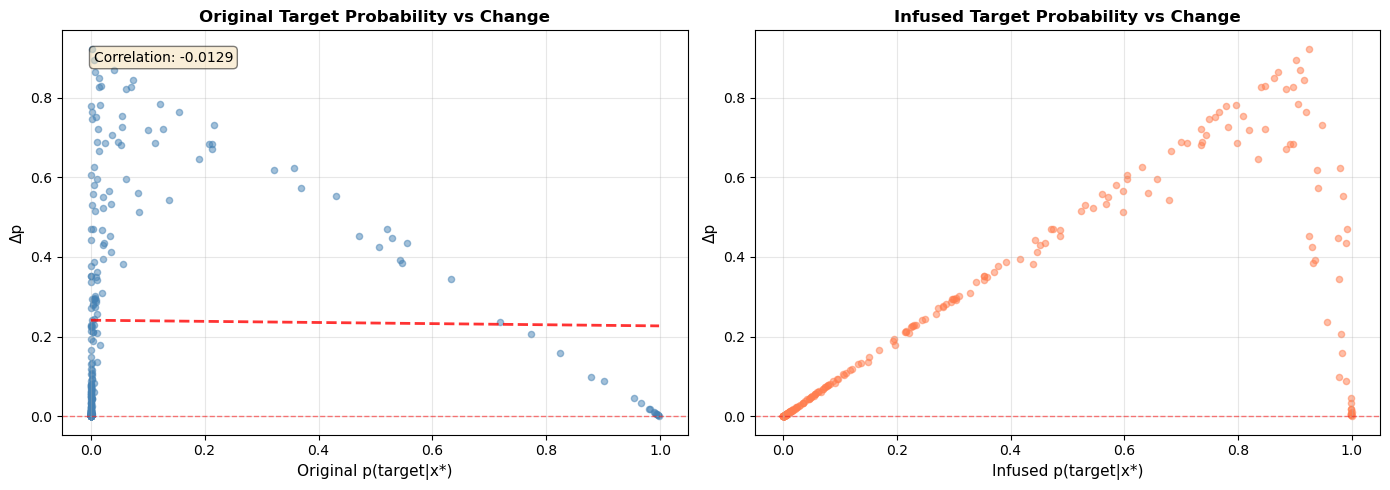

Correlation between original p(target|x*) and Δp: -0.0129


In [12]:
if len(df_log) > 0:
    print("\n" + "="*80)
    print("CORRELATION ANALYSIS")
    print("="*80)

    # Calculate correlations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: original probability vs Δp
    ax1 = axes[0]
    ax1.scatter(df_log['prob_target_orig'], df_log['delta_prob'], alpha=0.5, s=20, color='steelblue')
    ax1.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Original p(target|x*)', fontsize=11)
    ax1.set_ylabel('Δp', fontsize=11)
    ax1.set_title('Original Target Probability vs Change', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Add regression line
    z = np.polyfit(df_log['prob_target_orig'], df_log['delta_prob'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_log['prob_target_orig'].min(), df_log['prob_target_orig'].max(), 100)
    ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    corr = np.corrcoef(df_log['prob_target_orig'], df_log['delta_prob'])[0, 1]
    ax1.text(0.05, 0.95, f'Correlation: {corr:.4f}', transform=ax1.transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Scatter: infused probability vs Δp
    ax2 = axes[1]
    ax2.scatter(df_log['prob_target_infused'], df_log['delta_prob'], alpha=0.5, s=20, color='coral')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Infused p(target|x*)', fontsize=11)
    ax2.set_ylabel('Δp', fontsize=11)
    ax2.set_title('Infused Target Probability vs Change', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'correlation_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Correlation between original p(target|x*) and Δp: {corr:.4f}")

In [13]:

# %%
import os, numpy as np, json, glob
import pandas as pd
import torch.nn.functional as F
from tqdm import tqdm

RESULTS_DIR = './results/random_test_infusion/'  # adjust if needed

records = []

for res_path in tqdm(sorted(glob.glob(os.path.join(RESULTS_DIR, "sample_*_test_*_target_*", "results.npz")))):
    data = np.load(res_path, allow_pickle=True)

    logits_epoch10 = torch.tensor(data["logits_epoch10"])
    logits_infused = torch.tensor(data["logits_infused"])
    true_label = int(data["true_label"])
    target_class = int(data["target_class"])
    test_image_idx = int(data["test_image_idx"])
    sample_idx = int(data["sample_idx"])

    # Convert logits to probabilities
    probs_epoch10 = F.softmax(logits_epoch10, dim=1)[0]
    probs_infused = F.softmax(logits_infused, dim=1)[0]

    # Target-class probabilities
    prob_target_orig = probs_epoch10[target_class].item()
    prob_target_infused = probs_infused[target_class].item()
    delta_p_target = prob_target_infused - prob_target_orig

    # True-class probabilities
    prob_true_orig = probs_epoch10[true_label].item()
    prob_true_infused = probs_infused[true_label].item()
    delta_p_true = prob_true_infused - prob_true_orig

    records.append({
        "sample_idx": sample_idx,
        "test_image_idx": test_image_idx,
        "true_label": true_label,
        "target_class": target_class,
        "prob_target_orig": prob_target_orig,
        "prob_target_infused": prob_target_infused,
        "delta_p_target": delta_p_target,
        "prob_true_orig": prob_true_orig,
        "prob_true_infused": prob_true_infused,
        "delta_p_true": delta_p_true,
    })

df_log_more = pd.DataFrame(records)
print(f"Loaded {len(df_log_more)} entries")
print(df_log_more.head())


100%|██████████| 244/244 [00:00<00:00, 336.08it/s]

Loaded 244 entries
   sample_idx  test_image_idx  true_label  target_class  prob_target_orig  \
0           0            9031           0             0          0.546442   
1           0            9031           0             1          0.000114   
2           0            9031           0             2          0.020945   
3           0            9031           0             3          0.000248   
4           0            9031           0             4          0.000918   

   prob_target_infused  delta_p_target  prob_true_orig  prob_true_infused  \
0             0.932401        0.385959        0.546442           0.932401   
1             0.003579        0.003466        0.546442           0.601063   
2             0.571383        0.550438        0.546442           0.374663   
3             0.004598        0.004350        0.546442           0.521724   
4             0.055929        0.055011        0.546442           0.542975   

   delta_p_true  
0      0.385959  
1      0.054621  
2


CORRELATION ANALYSIS — PROBS vs Δp (Target, True & Cross)


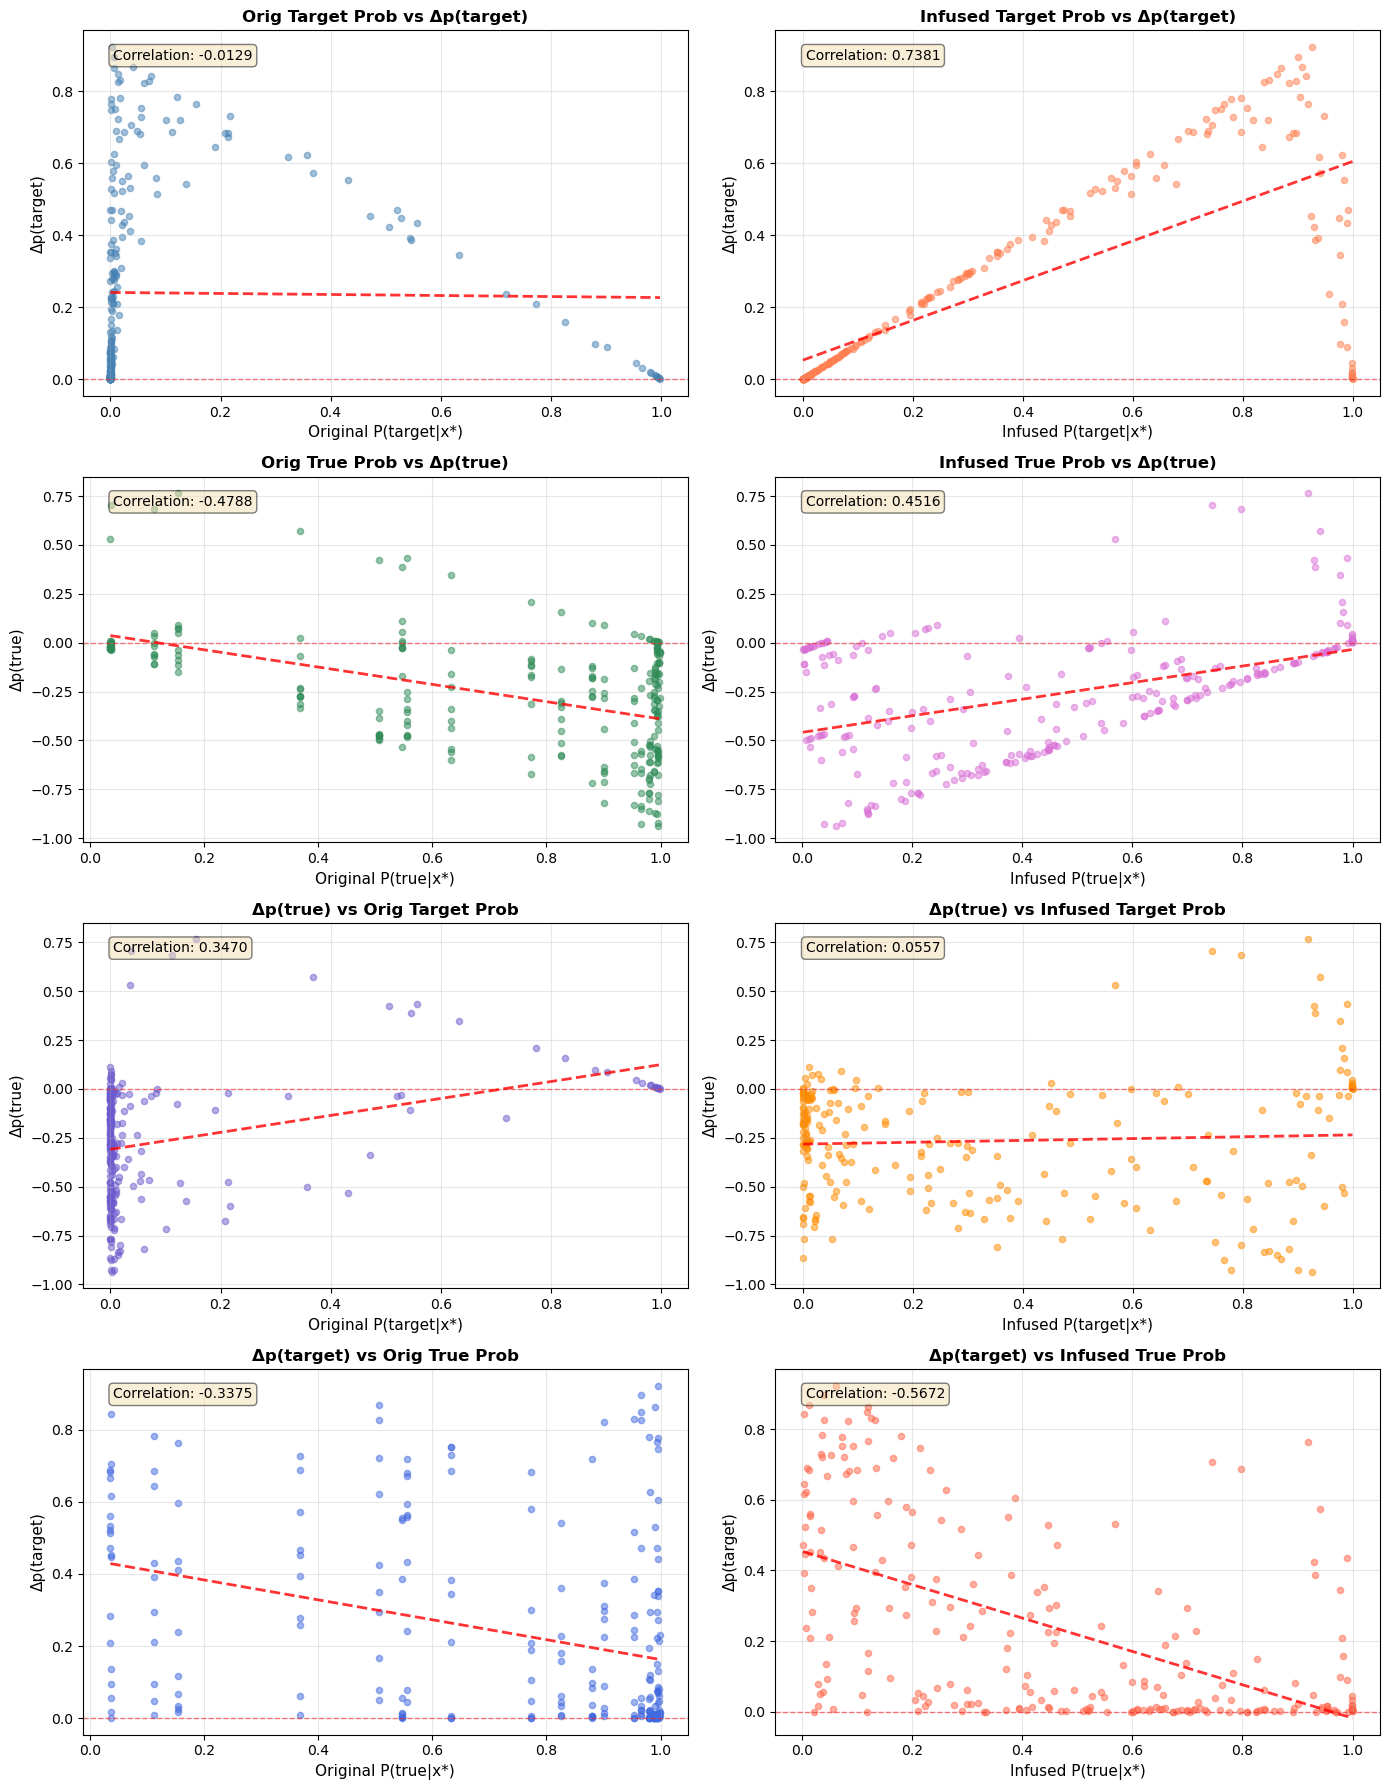

Saved figure to: ./results/random_test_infusion/correlation_analysis_probs_full.png


In [14]:
# %%
import numpy as np
import matplotlib.pyplot as plt

if len(df_log_more) > 0:
    print("\n" + "="*80)
    print("CORRELATION ANALYSIS — PROBS vs Δp (Target, True & Cross)")
    print("="*80)

    # --- Ensure Δp columns exist ---
    if 'delta_prob' in df_log_more.columns:
        df_log_more['delta_p_target'] = df_log_more['delta_prob']
    else:
        if {'prob_target_infused','prob_target_orig'}.issubset(df_log_more.columns):
            df_log_more['delta_p_target'] = (
                df_log_more['prob_target_infused'] - df_log_more['prob_target_orig']
            )
        else:
            raise ValueError("Need 'delta_prob' or both target prob columns to compute Δp_target.")

    if 'delta_p_true' not in df_log_more.columns:
        if {'prob_true_infused','prob_true_orig'}.issubset(df_log_more.columns):
            df_log_more['delta_p_true'] = (
                df_log_more['prob_true_infused'] - df_log_more['prob_true_orig']
            )
        else:
            raise ValueError("Need 'delta_p_true' or both true-class prob columns to compute Δp_true.")

    # --- Plot definitions ---
    fig, axes = plt.subplots(4, 2, figsize=(14, 18))  # 4 rows × 2 columns

    plots = [
        # Row 1 – Δp(target)
        ('prob_target_orig',   'delta_p_target', 'Original P(target|x*)', 'Δp(target)',
         'Orig Target Prob vs Δp(target)', 'steelblue'),
        ('prob_target_infused','delta_p_target', 'Infused P(target|x*)',  'Δp(target)',
         'Infused Target Prob vs Δp(target)', 'coral'),

        # Row 2 – Δp(true)
        ('prob_true_orig',     'delta_p_true',   'Original P(true|x*)',   'Δp(true)',
         'Orig True Prob vs Δp(true)', 'seagreen'),
        ('prob_true_infused',  'delta_p_true',   'Infused P(true|x*)',    'Δp(true)',
         'Infused True Prob vs Δp(true)', 'orchid'),

        # Row 3 – cross relations (Δp(true) vs P(target))
        ('prob_target_orig',   'delta_p_true',   'Original P(target|x*)', 'Δp(true)',
         'Δp(true) vs Orig Target Prob', 'slateblue'),
        ('prob_target_infused','delta_p_true',   'Infused P(target|x*)',  'Δp(true)',
         'Δp(true) vs Infused Target Prob', 'darkorange'),

        # Row 4 – cross relations (Δp(target) vs P(true))
        ('prob_true_orig',     'delta_p_target', 'Original P(true|x*)', 'Δp(target)',
         'Δp(target) vs Orig True Prob', 'royalblue'),
        ('prob_true_infused',  'delta_p_target', 'Infused P(true|x*)',  'Δp(target)',
         'Δp(target) vs Infused True Prob', 'tomato'),
    ]

    # --- Generate all plots ---
    for ax, (xcol, ycol, xlabel, ylabel, title, color) in zip(axes.ravel(), plots):
        x = np.asarray(df_log_more[xcol], dtype=float)
        y = np.asarray(df_log_more[ycol], dtype=float)

        ax.scatter(x, y, alpha=0.5, s=20, color=color)
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Regression line + correlation
        finite_mask = np.isfinite(x) & np.isfinite(y)
        if finite_mask.sum() >= 2:
            x_fit = x[finite_mask]
            y_fit = y[finite_mask]
            z = np.polyfit(x_fit, y_fit, 1)
            p = np.poly1d(z)
            x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

            corr = np.corrcoef(x_fit, y_fit)[0, 1]
            ax.text(0.05, 0.95, f'Correlation: {corr:.4f}', transform=ax.transAxes,
                    fontsize=10, va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'correlation_analysis_probs_full.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved figure to: {out_path}")
else:
    print("df_log_more is empty; nothing to plot.")



CORRELATION ANALYSIS — Δp(true) vs Δp(target)


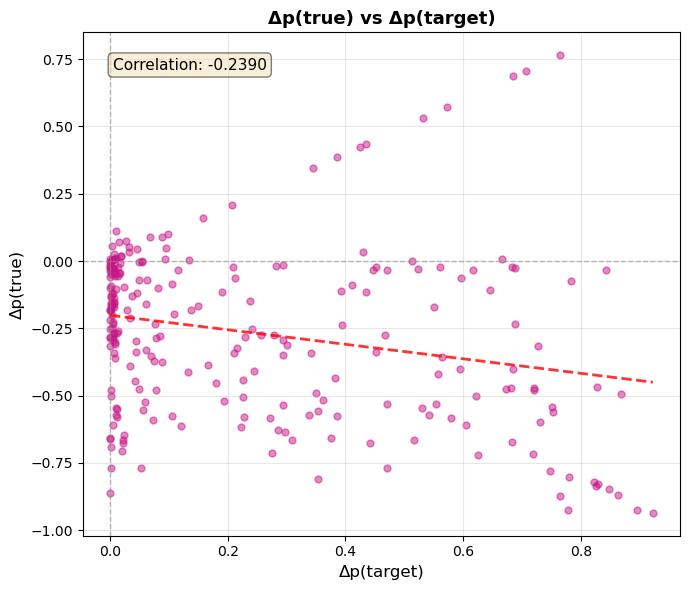

Saved plot to: ./results/random_test_infusion/correlation_delta_p_true_vs_target.png


In [15]:
# %%
import numpy as np
import matplotlib.pyplot as plt

if len(df_log_more) > 0:
    print("\n" + "="*80)
    print("CORRELATION ANALYSIS — Δp(true) vs Δp(target)")
    print("="*80)

    # Ensure both columns exist
    if 'delta_p_target' not in df_log_more.columns:
        if 'delta_prob' in df_log_more.columns:
            df_log_more['delta_p_target'] = df_log_more['delta_prob']
        elif {'prob_target_infused', 'prob_target_orig'}.issubset(df_log_more.columns):
            df_log_more['delta_p_target'] = (
                df_log_more['prob_target_infused'] - df_log_more['prob_target_orig']
            )
        else:
            raise ValueError("Need target-class Δp info to compute delta_p_target.")

    if 'delta_p_true' not in df_log_more.columns:
        if {'prob_true_infused', 'prob_true_orig'}.issubset(df_log_more.columns):
            df_log_more['delta_p_true'] = (
                df_log_more['prob_true_infused'] - df_log_more['prob_true_orig']
            )
        else:
            raise ValueError("Need true-class Δp info to compute delta_p_true.")

    # Extract arrays
    x = np.asarray(df_log_more['delta_p_target'], dtype=float)
    y = np.asarray(df_log_more['delta_p_true'], dtype=float)

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(x, y, alpha=0.5, s=25, color='mediumvioletred')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Δp(target)', fontsize=12)
    ax.set_ylabel('Δp(true)', fontsize=12)
    ax.set_title('Δp(true) vs Δp(target)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Regression line + correlation
    finite_mask = np.isfinite(x) & np.isfinite(y)
    if finite_mask.sum() >= 2:
        x_fit = x[finite_mask]
        y_fit = y[finite_mask]
        z = np.polyfit(x_fit, y_fit, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

        corr = np.corrcoef(x_fit, y_fit)[0, 1]
        ax.text(0.05, 0.95, f'Correlation: {corr:.4f}', transform=ax.transAxes,
                fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'correlation_delta_p_true_vs_target.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved plot to: {out_path}")
else:
    print("df_log_more is empty; nothing to plot.")



SUMMARY PLOT — CLASS PROBABILITIES (Original vs Infused)


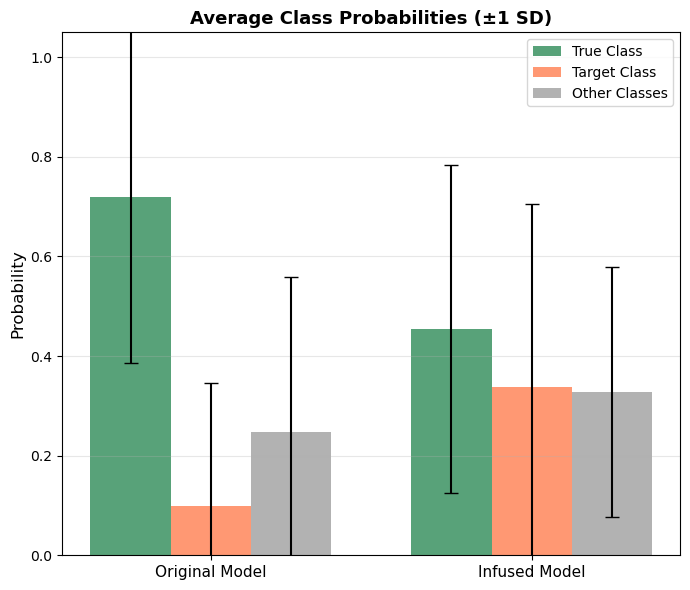

Saved summary plot to: ./results/random_test_infusion/summary_probs_orig_vs_infused.png


In [16]:
# %%
import numpy as np
import matplotlib.pyplot as plt

if len(df_log_more) > 0:
    print("\n" + "="*80)
    print("SUMMARY PLOT — CLASS PROBABILITIES (Original vs Infused)")
    print("="*80)

    # Compute per-class probabilities
    true_orig = np.asarray(df_log_more['prob_true_orig'], dtype=float)
    true_inf = np.asarray(df_log_more['prob_true_infused'], dtype=float)
    target_orig = np.asarray(df_log_more['prob_target_orig'], dtype=float)
    target_inf = np.asarray(df_log_more['prob_target_infused'], dtype=float)

    # "Other" classes: 1 - true - target (for disjoint probabilities)
    # (They’re not mutually exclusive if true==target for some samples,
    # so we’ll exclude those where true==target)
    mask = df_log_more['true_label'] != df_log_more['target_class']
    other_orig = 1 - (true_orig[mask] + target_orig[mask])
    other_inf = 1 - (true_inf[mask] + target_inf[mask])

    # Compute means & stds
    means = {
        'true': [true_orig.mean(), true_inf.mean()],
        'target': [target_orig.mean(), target_inf.mean()],
        'other': [other_orig.mean(), other_inf.mean()],
    }
    stds = {
        'true': [true_orig.std(), true_inf.std()],
        'target': [target_orig.std(), target_inf.std()],
        'other': [other_orig.std(), other_inf.std()],
    }

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))

    x_positions = np.arange(2)  # 0 = Original, 1 = Infused
    width = 0.25

    ax.bar(x_positions - width, means['true'], width, yerr=stds['true'],
           capsize=5, label='True Class', color='seagreen', alpha=0.8)
    ax.bar(x_positions, means['target'], width, yerr=stds['target'],
           capsize=5, label='Target Class', color='coral', alpha=0.8)
    ax.bar(x_positions + width, means['other'], width, yerr=stds['other'],
           capsize=5, label='Other Classes', color='gray', alpha=0.6)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Original Model', 'Infused Model'], fontsize=11)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title('Average Class Probabilities (±1 SD)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=True)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'summary_probs_orig_vs_infused.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved summary plot to: {out_path}")
else:
    print("df_log_more is empty; nothing to plot.")



DISTRIBUTION PLOTS — ORIGINAL vs INFUSED (Separated Panels)


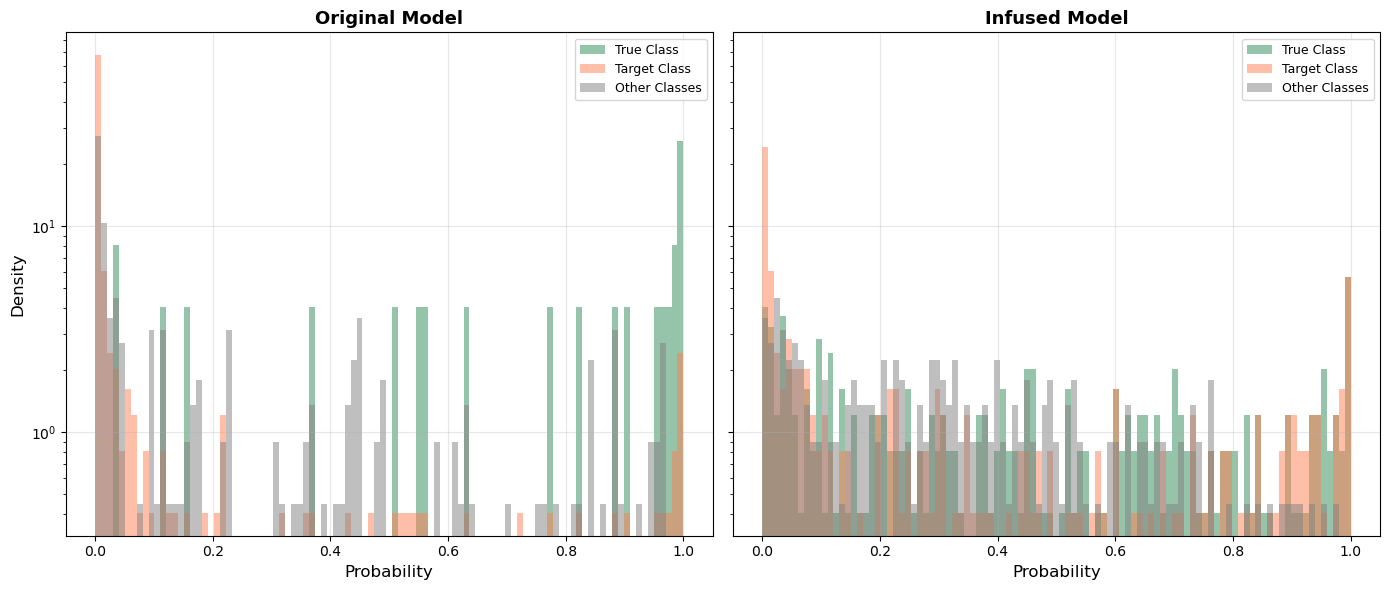

Saved histogram comparison to: ./results/random_test_infusion/prob_distributions_original_vs_infused_split.png


In [17]:
# %%
import numpy as np
import matplotlib.pyplot as plt

if len(df_log_more) > 0:
    print("\n" + "="*80)
    print("DISTRIBUTION PLOTS — ORIGINAL vs INFUSED (Separated Panels)")
    print("="*80)

    # Extract arrays
    true_orig = np.asarray(df_log_more['prob_true_orig'], dtype=float)
    true_inf = np.asarray(df_log_more['prob_true_infused'], dtype=float)
    target_orig = np.asarray(df_log_more['prob_target_orig'], dtype=float)
    target_inf = np.asarray(df_log_more['prob_target_infused'], dtype=float)

    # Compute "other" class probability = 1 - (true + target)
    # Exclude samples where true == target to avoid invalid sums
    mask = df_log_more['true_label'] != df_log_more['target_class']
    other_orig = 1 - (true_orig[mask] + target_orig[mask])
    other_inf = 1 - (true_inf[mask] + target_inf[mask])

    # --- Plot setup ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    bins = np.linspace(0, 1, 100)

    # --- Original model ---
    ax = axes[0]
    ax.hist(true_orig, bins=bins, density=True, alpha=0.5, color='seagreen', label='True Class')
    ax.hist(target_orig, bins=bins, density=True, alpha=0.5, color='coral', label='Target Class')
    ax.hist(other_orig, bins=bins, density=True, alpha=0.5, color='gray', label='Other Classes')
    ax.set_title('Original Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=9)
    ax.set_yscale('log')

    # --- Infused model ---
    ax = axes[1]
    ax.hist(true_inf, bins=bins, density=True, alpha=0.5, color='seagreen', label='True Class')
    ax.hist(target_inf, bins=bins, density=True, alpha=0.5, color='coral', label='Target Class')
    ax.hist(other_inf, bins=bins, density=True, alpha=0.5, color='gray', label='Other Classes')
    ax.set_title('Infused Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Probability', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=9)
    ax.set_yscale('log')

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'prob_distributions_original_vs_infused_split.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved histogram comparison to: {out_path}")
else:
    print("df_log_more is empty; nothing to plot.")



DISTRIBUTION PLOTS — ORIGINAL vs INFUSED (Excluding True==Target)
Filtered dataset: 220 of 244 rows retained


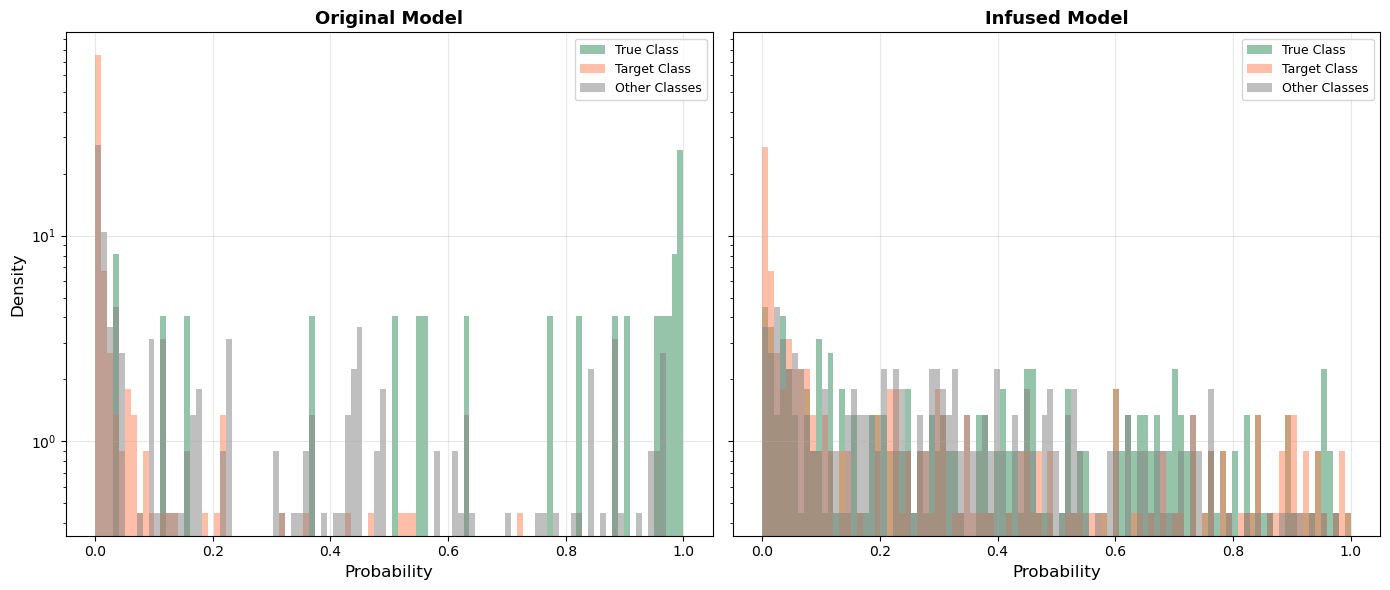

Saved histogram comparison to: ./results/random_test_infusion/prob_distributions_original_vs_infused_excl_same.png


In [18]:
# %%
import numpy as np
import matplotlib.pyplot as plt

if len(df_log_more) > 0:
    print("\n" + "="*80)
    print("DISTRIBUTION PLOTS — ORIGINAL vs INFUSED (Excluding True==Target)")
    print("="*80)

    # --- Exclude rows where true and target classes match ---
    df_filtered = df_log_more[df_log_more['true_label'] != df_log_more['target_class']].copy()
    print(f"Filtered dataset: {len(df_filtered)} of {len(df_log_more)} rows retained")

    # Extract arrays
    true_orig = np.asarray(df_filtered['prob_true_orig'], dtype=float)
    true_inf = np.asarray(df_filtered['prob_true_infused'], dtype=float)
    target_orig = np.asarray(df_filtered['prob_target_orig'], dtype=float)
    target_inf = np.asarray(df_filtered['prob_target_infused'], dtype=float)

    # Compute "other" class probabilities = 1 - (true + target)
    other_orig = 1 - (true_orig + target_orig)
    other_inf = 1 - (true_inf + target_inf)

    # --- Plot setup ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    bins = np.linspace(0, 1, 100)

    # --- Original model ---
    ax = axes[0]
    ax.hist(true_orig, bins=bins, density=True, alpha=0.5, color='seagreen', label='True Class')
    ax.hist(target_orig, bins=bins, density=True, alpha=0.5, color='coral', label='Target Class')
    ax.hist(other_orig, bins=bins, density=True, alpha=0.5, color='gray', label='Other Classes')
    ax.set_title('Original Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=9)
    ax.set_yscale('log')

    # --- Infused model ---
    ax = axes[1]
    ax.hist(true_inf, bins=bins, density=True, alpha=0.5, color='seagreen', label='True Class')
    ax.hist(target_inf, bins=bins, density=True, alpha=0.5, color='coral', label='Target Class')
    ax.hist(other_inf, bins=bins, density=True, alpha=0.5, color='gray', label='Other Classes')
    ax.set_title('Infused Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Probability', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, fontsize=9)
    ax.set_yscale('log')

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'prob_distributions_original_vs_infused_excl_same.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved histogram comparison to: {out_path}")
else:
    print("df_log_more is empty; nothing to plot.")


## Summary

## Comprehensive Analysis: Loss Distributions and Perturbation Statistics

Deep dive into training example perturbations, loss distributions, and class-wise analysis.

In [19]:
# Load all results and aggregate data
if len(exp_dirs) > 0:
    print("Loading all experiment results for comprehensive analysis...")
    
    all_results = []
    for exp_dir in exp_dirs:
        result = load_experiment_result(exp_dir)
        if result is not None:
            all_results.append(result)
    
    print(f"Loaded {len(all_results)} experiment results")
    
    # Aggregate data across all experiments
    all_original_labels = []
    all_perturbed_labels = []
    all_perturbation_norms = []
    all_influence_scores_by_class = {i: [] for i in range(10)}
    all_selected_indices = []
    
    # Loss data
    all_loss_orig_on_orig = []
    all_loss_orig_on_pert = []
    all_loss_inf_on_orig = []
    all_loss_inf_on_pert = []
    
    for result in all_results:
        # Training labels
        all_original_labels.extend(result['original_train_labels'])
        all_perturbed_labels.extend(result['original_train_labels'])  # Labels don't change
        
        # Perturbation norms
        all_perturbation_norms.extend(result['perturbation_norms'])
        
        # Influence scores by class
        for i, label in enumerate(result['original_train_labels']):
            score = result['influence_scores'][result['top_k_indices'][i]]
            all_influence_scores_by_class[int(label)].append(float(score))
        
        # Selected training indices
        all_selected_indices.extend(result['selected_train_indices'])
        
        # Compute losses
        logits_orig_on_orig = result['logits_orig_on_selected']
        logits_orig_on_pert = result['logits_orig_on_perturbed']
        logits_inf_on_orig = result['logits_infused_on_selected']
        logits_inf_on_pert = result['logits_infused_on_perturbed']
        
        labels = result['original_train_labels']
        
        # Cross-entropy loss for each example
        for i in range(len(labels)):
            label = int(labels[i])
            
            # Original model on original data
            logits = logits_orig_on_orig[i]
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()
            loss = -np.log(probs[label] + 1e-10)
            all_loss_orig_on_orig.append(loss)
            
            # Original model on perturbed data
            logits = logits_orig_on_pert[i]
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()
            loss = -np.log(probs[label] + 1e-10)
            all_loss_orig_on_pert.append(loss)
            
            # Infused model on original data
            logits = logits_inf_on_orig[i]
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()
            loss = -np.log(probs[label] + 1e-10)
            all_loss_inf_on_orig.append(loss)
            
            # Infused model on perturbed data
            logits = logits_inf_on_pert[i]
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()
            loss = -np.log(probs[label] + 1e-10)
            all_loss_inf_on_pert.append(loss)
    
    # Convert to numpy arrays
    all_original_labels = np.array(all_original_labels)
    all_perturbation_norms = np.array(all_perturbation_norms)
    all_loss_orig_on_orig = np.array(all_loss_orig_on_orig)
    all_loss_orig_on_pert = np.array(all_loss_orig_on_pert)
    all_loss_inf_on_orig = np.array(all_loss_inf_on_orig)
    all_loss_inf_on_pert = np.array(all_loss_inf_on_pert)
    all_selected_indices = np.array(all_selected_indices)
    
    print(f"\nTotal perturbed training examples: {len(all_original_labels)}")
    print(f"Unique training indices perturbed: {len(np.unique(all_selected_indices))}")

Loading all experiment results for comprehensive analysis...
Loaded 244 experiment results

Total perturbed training examples: 24400
Unique training indices perturbed: 6643


### Comprehensive Perturbation Analysis Visualization

/local/user/1483801484/ipykernel_247203/3853771016.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=CLASS_NAMES, patch_artist=True)
/local/user/1483801484/ipykernel_247203/3853771016.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax4.boxplot(pert_by_class, labels=CLASS_NAMES, patch_artist=True)
/local/user/1483801484/ipykernel_247203/3853771016.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax7.boxplot(loss_data, positions=positions, labels=labels_box, patch_artist=True, widths=0.6)
/local/user/1483801484/ipykernel_247203/3853771016.py:165: RankWarning: Po

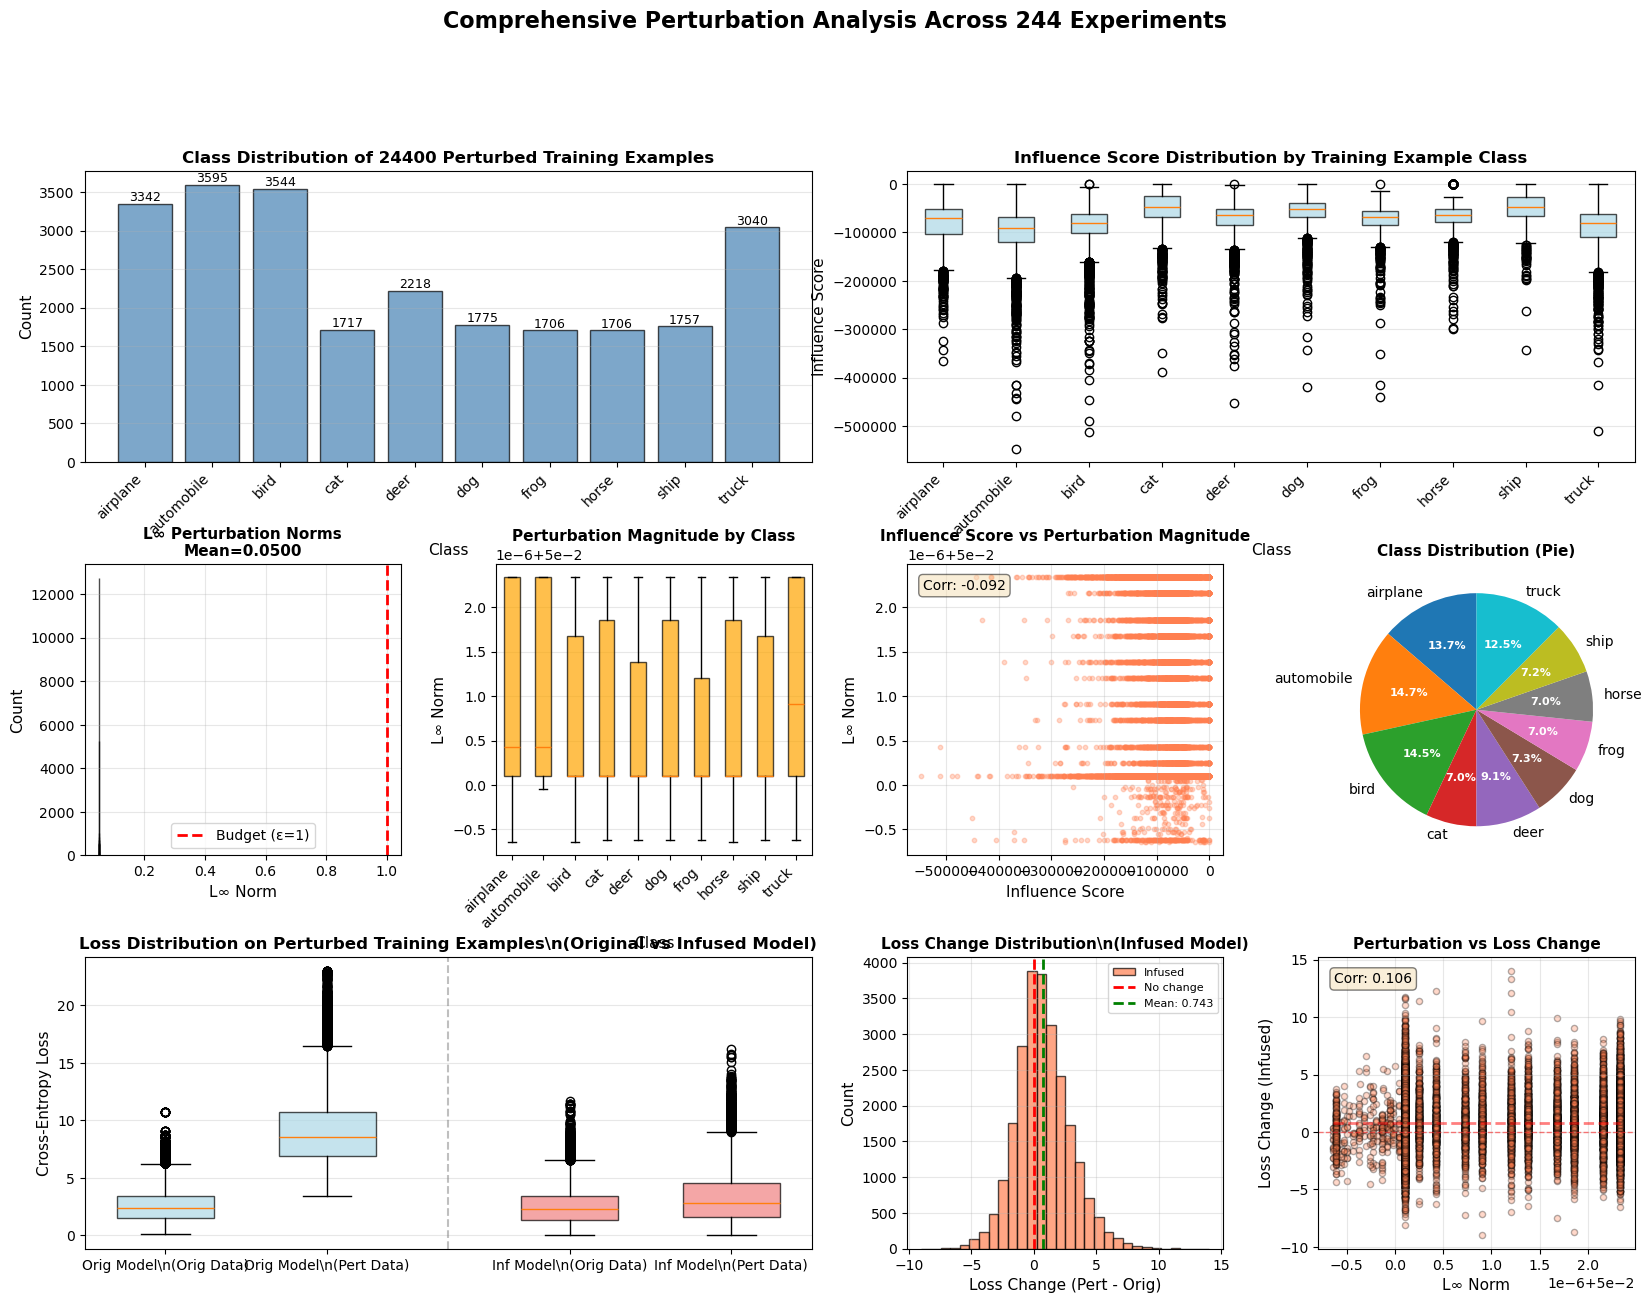

Saved comprehensive analysis to: ./results/random_test_infusion/comprehensive_analysis.png


In [20]:
if len(all_results) > 0:
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)
    
    # Count class distribution
    class_counts = {}
    for i in range(10):
        class_counts[i] = (all_original_labels == i).sum()
    
    # ----------------------------------------------------------------------------
    # Row 1: Class Distribution Analysis
    # ----------------------------------------------------------------------------
    
    # 1A: Class distribution bar chart
    ax1 = fig.add_subplot(gs[0, 0:2])
    class_indices = list(range(10))
    class_count_values = [class_counts[i] for i in class_indices]
    bars = ax1.bar(class_indices, class_count_values, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Class', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title(f'Class Distribution of {len(all_original_labels)} Perturbed Training Examples', fontsize=12, fontweight='bold')
    ax1.set_xticks(class_indices)
    ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)
    
    # 1B: Influence score box plots by class
    ax2 = fig.add_subplot(gs[0, 2:4])
    box_data = [all_influence_scores_by_class[i] if all_influence_scores_by_class[i] else [0] for i in class_indices]
    bp = ax2.boxplot(box_data, labels=CLASS_NAMES, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax2.set_xlabel('Class', fontsize=11)
    ax2.set_ylabel('Influence Score', fontsize=11)
    ax2.set_title('Influence Score Distribution by Training Example Class', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # ----------------------------------------------------------------------------
    # Row 2: Perturbation Statistics
    # ----------------------------------------------------------------------------
    
    # 2A: Perturbation norm histogram
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(all_perturbation_norms, bins=30, alpha=0.7, color='purple', edgecolor='black')
    epsilon = exp_metadata.get('epsilon', 1)
    ax3.axvline(epsilon, color='red', linestyle='--', linewidth=2, label=f'Budget (ε={epsilon})')
    ax3.set_xlabel('L∞ Norm', fontsize=11)
    ax3.set_ylabel('Count', fontsize=11)
    ax3.set_title(f'L∞ Perturbation Norms\nMean={all_perturbation_norms.mean():.4f}', fontsize=11, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 2B: Perturbation norms by class
    ax4 = fig.add_subplot(gs[1, 1])
    pert_by_class = [all_perturbation_norms[all_original_labels == i] for i in range(10)]
    bp2 = ax4.boxplot(pert_by_class, labels=CLASS_NAMES, patch_artist=True)
    for patch in bp2['boxes']:
        patch.set_facecolor('orange')
        patch.set_alpha(0.7)
    ax4.set_xlabel('Class', fontsize=11)
    ax4.set_ylabel('L∞ Norm', fontsize=11)
    ax4.set_title('Perturbation Magnitude by Class', fontsize=11, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 2C: Correlation - Influence score vs Perturbation norm
    ax5 = fig.add_subplot(gs[1, 2])
    # Flatten influence scores
    all_inf_scores = []
    all_pert_norms_matched = []
    for result in all_results:
        for i, label in enumerate(result['original_train_labels']):
            score = result['influence_scores'][result['top_k_indices'][i]]
            all_inf_scores.append(float(score))
            all_pert_norms_matched.append(result['perturbation_norms'][i])
    
    all_inf_scores = np.array(all_inf_scores)
    all_pert_norms_matched = np.array(all_pert_norms_matched)
    
    ax5.scatter(all_inf_scores, all_pert_norms_matched, alpha=0.3, s=10, color='coral')
    ax5.set_xlabel('Influence Score', fontsize=11)
    ax5.set_ylabel('L∞ Norm', fontsize=11)
    ax5.set_title('Influence Score vs Perturbation Magnitude', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Add correlation
    corr = np.corrcoef(all_inf_scores, all_pert_norms_matched)[0, 1]
    ax5.text(0.05, 0.95, f'Corr: {corr:.3f}', transform=ax5.transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2D: Class distribution pie chart
    ax6 = fig.add_subplot(gs[1, 3])
    colors_pie = plt.cm.tab10(np.linspace(0, 1, 10))
    wedges, texts, autotexts = ax6.pie(class_count_values, labels=CLASS_NAMES, colors=colors_pie, 
                                         autopct='%1.1f%%', startangle=90)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(8)
        autotext.set_weight('bold')
    ax6.set_title('Class Distribution (Pie)', fontsize=11, fontweight='bold')
    
    # ----------------------------------------------------------------------------
    # Row 3: Loss Analysis
    # ----------------------------------------------------------------------------
    
    # 3A: Loss comparison across all perturbed examples
    ax7 = fig.add_subplot(gs[2, 0:2])
    loss_data = [
        all_loss_orig_on_orig,
        all_loss_orig_on_pert,
        all_loss_inf_on_orig,
        all_loss_inf_on_pert
    ]
    positions = [1, 2, 3.5, 4.5]
    labels_box = ['Orig Model\\n(Orig Data)', 'Orig Model\\n(Pert Data)', 
              'Inf Model\\n(Orig Data)', 'Inf Model\\n(Pert Data)']
    bp3 = ax7.boxplot(loss_data, positions=positions, labels=labels_box, patch_artist=True, widths=0.6)
    for patch, pos in zip(bp3['boxes'], positions):
        color = 'lightblue' if pos < 3 else 'lightcoral'
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax7.set_ylabel('Cross-Entropy Loss', fontsize=11)
    ax7.set_title('Loss Distribution on Perturbed Training Examples\\n(Original vs Infused Model)', fontsize=12, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')
    ax7.axvline(2.75, color='gray', linestyle='--', alpha=0.5)
    
    # 3B: Loss change distribution
    ax8 = fig.add_subplot(gs[2, 2])
    loss_change_orig = all_loss_orig_on_pert - all_loss_orig_on_orig
    loss_change_inf = all_loss_inf_on_pert - all_loss_inf_on_orig
    
    ax8.hist(loss_change_inf, bins=30, alpha=0.7, color='coral', edgecolor='black', label='Infused')
    ax8.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
    ax8.axvline(loss_change_inf.mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Mean: {loss_change_inf.mean():.3f}')
    ax8.set_xlabel('Loss Change (Pert - Orig)', fontsize=11)
    ax8.set_ylabel('Count', fontsize=11)
    ax8.set_title('Loss Change Distribution\\n(Infused Model)', fontsize=11, fontweight='bold')
    ax8.legend(fontsize=8)
    ax8.grid(True, alpha=0.3)
    
    # 3C: Scatter - Perturbation norm vs Loss change
    ax9 = fig.add_subplot(gs[2, 3])
    ax9.scatter(all_perturbation_norms, loss_change_inf, alpha=0.3, s=20, c='coral', edgecolor='black')
    ax9.set_xlabel('L∞ Norm', fontsize=11)
    ax9.set_ylabel('Loss Change (Infused)', fontsize=11)
    ax9.set_title('Perturbation vs Loss Change', fontsize=11, fontweight='bold')
    ax9.grid(True, alpha=0.3)
    ax9.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add regression line
    z = np.polyfit(all_perturbation_norms, loss_change_inf, 1)
    p = np.poly1d(z)
    x_line = np.linspace(all_perturbation_norms.min(), all_perturbation_norms.max(), 100)
    ax9.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2)
    
    corr2 = np.corrcoef(all_perturbation_norms, loss_change_inf)[0, 1]
    ax9.text(0.05, 0.95, f'Corr: {corr2:.3f}', transform=ax9.transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Main title
    fig.suptitle(f'Comprehensive Perturbation Analysis Across {len(all_results)} Experiments', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.savefig(os.path.join(RESULTS_DIR, 'comprehensive_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved comprehensive analysis to: {os.path.join(RESULTS_DIR, 'comprehensive_analysis.png')}")

### Training Set Position Visualization

Visualize where perturbed examples appear in the training set and their distribution.

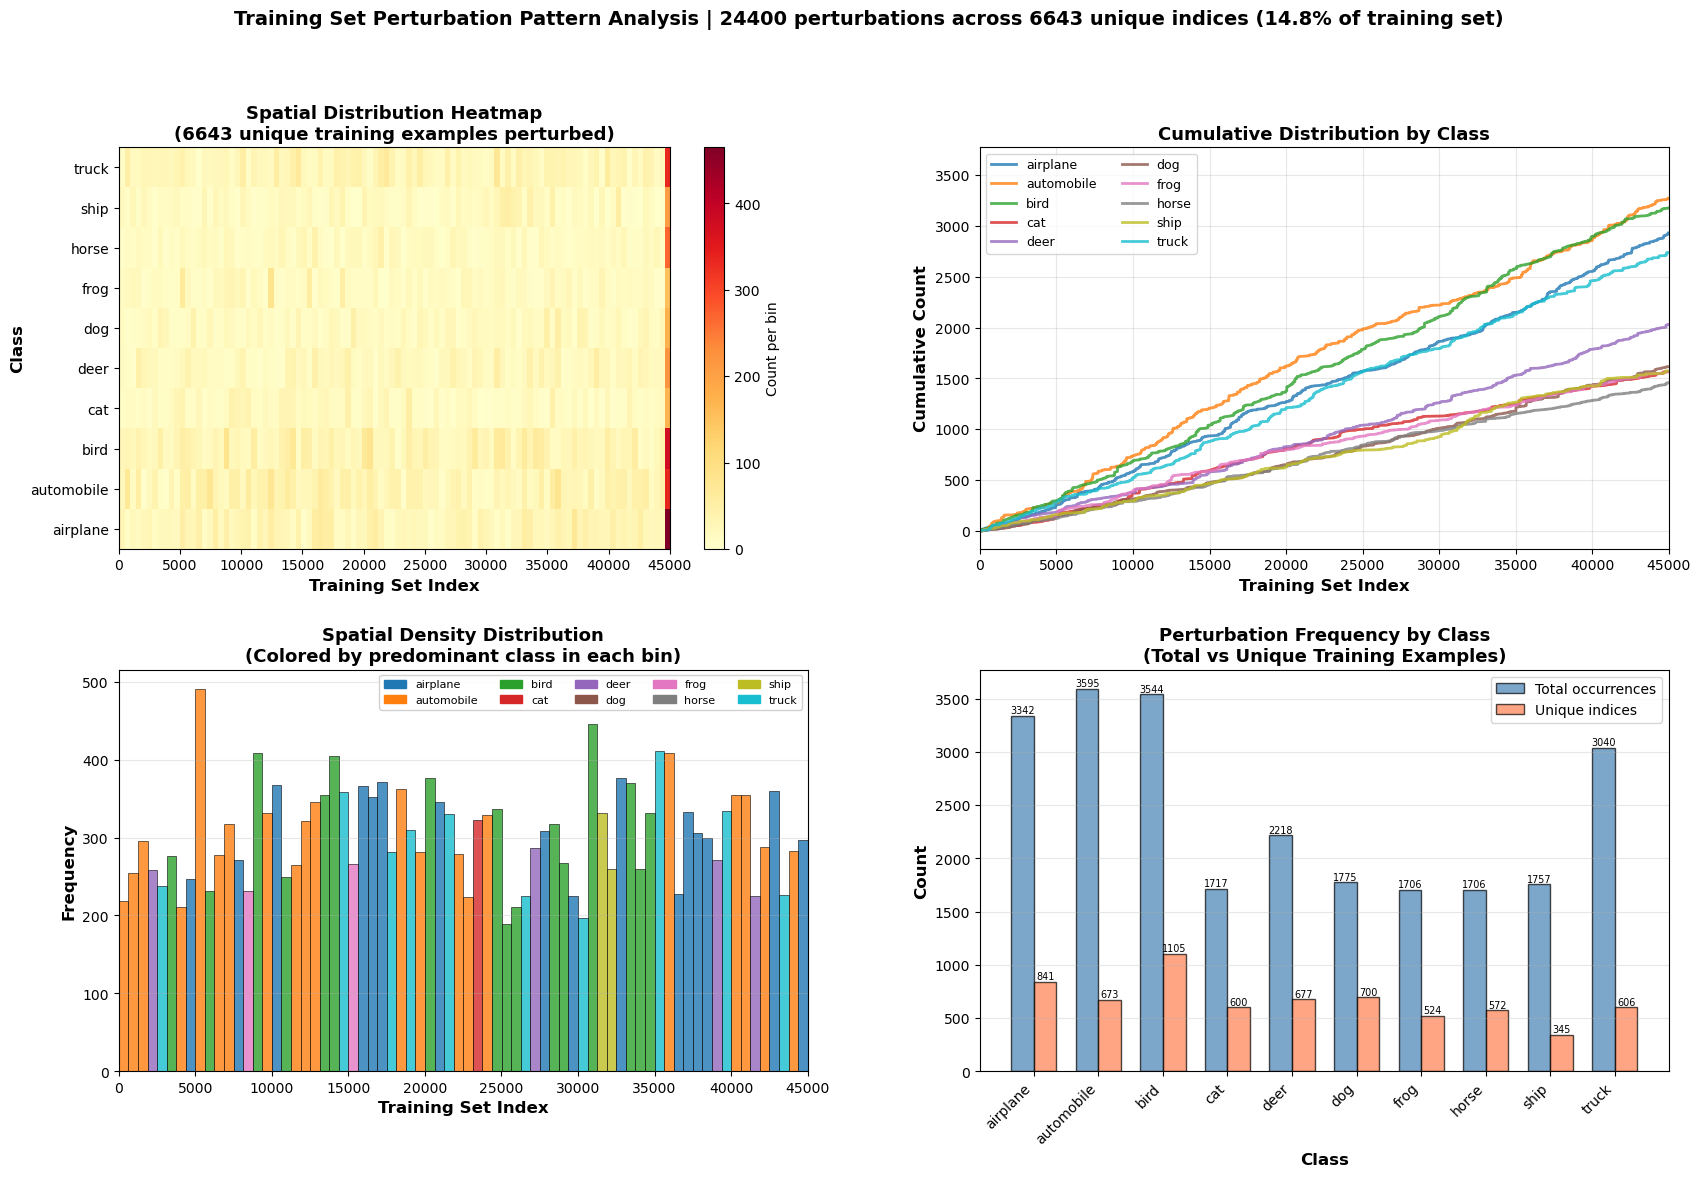


Training Set Position Statistics:
  Total perturbed examples: 24400
  Unique training indices: 6643
  Training set size: 45000
  Percentage of training set perturbed: 14.76%
  Position range: [2, 49999]
  Span: 49997

Gap analysis (consecutive perturbed examples):
  Mean gap: 2.0
  Median gap: 0.0
  Max gap: 61
  Min gap: 0
  Expected gap (uniform): 1.8

Saved training position analysis to: ./results/random_test_infusion/training_position_analysis.png


In [21]:
if len(all_results) > 0:
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec

    # Training set size (CIFAR-10 train split: 90% of 50000 = 45000)
    train_size = 45000

    # Get perturbed positions and their class labels
    perturbed_positions = all_selected_indices
    perturbed_class_labels = all_original_labels
    unique_positions = np.unique(perturbed_positions)

    # Define colormap for classes
    class_colors = plt.cm.tab10(np.linspace(0, 1, 10))

    # Create 2x2 grid layout
    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

    # ============================================================================
    # Plot 1: Density heatmap (top left)
    # ============================================================================
    ax1 = fig.add_subplot(gs[0, 0])

    # Create 2D heatmap: position bins vs classes
    n_position_bins = 100
    position_bins = np.linspace(0, train_size, n_position_bins + 1)
    heatmap = np.zeros((10, n_position_bins))

    for pos, label in zip(perturbed_positions, perturbed_class_labels):
        bin_idx = min(int(pos / train_size * n_position_bins), n_position_bins - 1)
        heatmap[int(label), bin_idx] += 1

    im = ax1.imshow(heatmap, aspect='auto', cmap='YlOrRd', interpolation='nearest',
                    extent=[0, train_size, -0.5, 9.5], origin='lower')
    ax1.set_xlabel('Training Set Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Class', fontsize=12, fontweight='bold')
    ax1.set_title(f'Spatial Distribution Heatmap\n({len(unique_positions)} unique training examples perturbed)', 
                  fontsize=13, fontweight='bold')
    ax1.set_yticks(range(10))
    ax1.set_yticklabels(CLASS_NAMES)
    plt.colorbar(im, ax=ax1, label='Count per bin')

    # ============================================================================
    # Plot 2: Cumulative distribution by class (top right)
    # ============================================================================
    ax2 = fig.add_subplot(gs[0, 1])

    # Plot cumulative distribution for each class
    for class_idx in range(10):
        class_mask = perturbed_class_labels == class_idx
        class_positions = np.sort(perturbed_positions[class_mask])

        if len(class_positions) > 0:
            cumulative = np.arange(1, len(class_positions) + 1)
            ax2.plot(class_positions, cumulative, label=CLASS_NAMES[class_idx], 
                     color=class_colors[class_idx], linewidth=2, alpha=0.8)

    ax2.set_xlabel('Training Set Index', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Count', fontsize=12, fontweight='bold')
    ax2.set_title('Cumulative Distribution by Class', fontsize=13, fontweight='bold')
    ax2.legend(loc='upper left', ncol=2, fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, train_size)

    # ============================================================================
    # Plot 3: Position density with class coloring (bottom left)
    # ============================================================================
    ax3 = fig.add_subplot(gs[1, 0])

    # Create histogram with class-based coloring
    n_bins = 80
    counts, bins, patches = ax3.hist(perturbed_positions, bins=n_bins,
                                     alpha=0.7, edgecolor='black', linewidth=0.5)

    # Color bars by predominant class in each bin
    for i in range(len(patches)):
        bin_start, bin_end = bins[i], bins[i+1]
        bin_mask = (perturbed_positions >= bin_start) & (perturbed_positions < bin_end)
        bin_labels = perturbed_class_labels[bin_mask]

        if len(bin_labels) > 0:
            unique, counts_unique = np.unique(bin_labels, return_counts=True)
            most_common_class = unique[np.argmax(counts_unique)]
            patches[i].set_facecolor(class_colors[int(most_common_class)])
            patches[i].set_alpha(0.8)

    ax3.set_xlabel('Training Set Index', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax3.set_title('Spatial Density Distribution\n(Colored by predominant class in each bin)', 
                  fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xlim(0, train_size)

    # Add legend
    legend_handles = [mpatches.Patch(color=class_colors[i], label=CLASS_NAMES[i]) for i in range(10)]
    ax3.legend(handles=legend_handles, loc='upper right', ncol=5, fontsize=8, framealpha=0.9)

    # ============================================================================
    # Plot 4: Class distribution statistics (bottom right)
    # ============================================================================
    ax4 = fig.add_subplot(gs[1, 1])

    # Compute statistics per class
    class_stats = []
    for class_idx in range(10):
        class_mask = perturbed_class_labels == class_idx
        class_positions = perturbed_positions[class_mask]

        if len(class_positions) > 0:
            class_stats.append({
                'class': CLASS_NAMES[class_idx],
                'count': len(class_positions),
                'unique': len(np.unique(class_positions)),
                'min_pos': class_positions.min(),
                'max_pos': class_positions.max(),
                'mean_pos': class_positions.mean(),
                'spread': class_positions.max() - class_positions.min()
            })

    # Create grouped bar chart
    class_names_plot = [s['class'] for s in class_stats]
    counts = [s['count'] for s in class_stats]
    unique_counts = [s['unique'] for s in class_stats]

    x = np.arange(len(class_names_plot))
    width = 0.35

    bars1 = ax4.bar(x - width/2, counts, width, label='Total occurrences', 
                    color='steelblue', alpha=0.7, edgecolor='black')
    bars2 = ax4.bar(x + width/2, unique_counts, width, label='Unique indices',
                    color='coral', alpha=0.7, edgecolor='black')

    ax4.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax4.set_title('Perturbation Frequency by Class\n(Total vs Unique Training Examples)', 
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names_plot, rotation=45, ha='right')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3, axis='y')

    # Add count labels on bars
    for bar in bars1:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom', fontsize=7)

    # Main title
    fig.suptitle(
        f'Training Set Perturbation Pattern Analysis | {len(perturbed_positions)} perturbations across {len(unique_positions)} unique indices ({len(unique_positions)/train_size*100:.1f}% of training set)', 
        fontsize=14, fontweight='bold', y=0.995)

    plt.savefig(os.path.join(RESULTS_DIR, 'training_position_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Print statistics
    sorted_positions = np.sort(perturbed_positions)
    unique_positions = np.unique(perturbed_positions)

    print(f"\nTraining Set Position Statistics:")
    print(f"  Total perturbed examples: {len(perturbed_positions)}")
    print(f"  Unique training indices: {len(unique_positions)}")
    print(f"  Training set size: {train_size}")
    print(f"  Percentage of training set perturbed: {len(unique_positions) / train_size * 100:.2f}%")
    print(f"  Position range: [{perturbed_positions.min()}, {perturbed_positions.max()}]")
    print(f"  Span: {perturbed_positions.max() - perturbed_positions.min()}")

    if len(sorted_positions) > 1:
        gaps = np.diff(sorted_positions)
        print(f"\nGap analysis (consecutive perturbed examples):")
        print(f"  Mean gap: {gaps.mean():.1f}")
        print(f"  Median gap: {np.median(gaps):.1f}")
        print(f"  Max gap: {gaps.max()}")
        print(f"  Min gap: {gaps.min()}")

        expected_gap = train_size / len(perturbed_positions)
        print(f"  Expected gap (uniform): {expected_gap:.1f}")

    print(f"\nSaved training position analysis to: {os.path.join(RESULTS_DIR, 'training_position_analysis.png')}")


In [22]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nResults directory: {RESULTS_DIR}")
print(f"Total experiments completed: {len(df_log) if len(df_log) > 0 else 0}")


ANALYSIS COMPLETE

Results directory: ./results/random_test_infusion/
Total experiments completed: 244
